# Exploratory Analysis of Notable People Dataset

## Dataset

**Source:** Biographical dataset of notable people from Wikidata, covering people born in the 20th and 21st centuries.  
**Link:** https://www.kaggle.com/datasets/qqsolov/notable-people-dataset-wikidata-based/data  
**Size:** 417,937 records across 18 columns (reduced to 12 working columns after dropping irrelevant fields).

Core columns used in this analysis: `label`, `date_of_birth`, `country_of_birth`, `occupations`, `occupation_groups`, `sex_or_gender`.

---

## What I Analyzed

This notebook explores patterns in a dataset of notable people, focusing on:

- **Birth date patterns** : whether birth month or season has any unusual distribution, and how to handle data quality issues (e.g., placeholder January 1 birthdays)
- **Occupation over time** : how the mix of notable people by occupation group shifts across birth decades
- **Geography and occupation** : which countries produce the most notable people in specific fields
- **Gender representation** : how gender breaks down across occupation groups and changes over birth decades
- **Arts & Culture deep dive** : trends in creative sub-types (actors, musicians, writers, directors, etc.) by decade and country
- **Science & Academia deep dive** : top countries by scientific discipline
- **Pattern discovery** : unsupervised clustering to see whether people naturally group into meaningful profiles

---

## What I Did

1. Loaded the dataset and dropped columns not relevant to this analysis (death records, image/signature URLs).
2. Cleaned missing values: dropped records with no gender info (0.1%)
3. Mapped gender labels into four groups: male, female, trans, non-binary/gender diverse.
4. Engineered date features: birth month, birth month name, birth day, birth year, birth decade, birth season.
5. Identified and flagged January 1 birthdays as likely placeholder dates; created a cleaned dataset (`df`) excluding these for birth month analysis.
6. Ran grouped comparisons, cross-tabulations, and visualizations across occupation, gender, geography, and time.
7. Applied MiniBatch K-Means clustering to discover natural groupings in the data.

---

## Important Considerations

This dataset represents *notable* people, not the general population. Patterns reflect trends within this dataset and should not be treated as universal claims about countries, genders, or occupations.

Results may also reflect historical, geographic, gender, documentation, and selection biases around modern, public-facing occupations that are easier to document.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
notable = pd.read_parquet('data/raw/npd_wikidata.parquet')

## Data Quality

Total rows: 417,937 rows and 12 columns. 
Core columns: `label`, `date_of_birth`, `country_of_birth`, `occupations`, and `occupation_groups`, `sex_or_gender`

Missing Values: 
`sex_or_gender` : will drop these since I can't infer - only 411 rows (about 0.1%)

Supplemental features that are not as important for my analysis: `awards`, `citizenships`, `place_of_birth`, `name_in_native_languages`, and `pseudonyms`

In [3]:
drop_col = notable[['place_of_death','date_of_death', 'country_of_death', 'signature_url', 'image_url',  'date_of_image']]
notable = notable.drop(columns=drop_col)

In [4]:
notable.isna().mean().sort_values(ascending=False) * 100

pseudonyms                  96.918435
awards                      76.071274
name_in_native_languages    76.066728
citizenships                 4.346827
place_of_birth               0.352924
sex_or_gender                0.098340
wikidata_url                 0.000000
label                        0.000000
date_of_birth                0.000000
country_of_birth             0.000000
occupations                  0.000000
occupation_groups            0.000000
dtype: float64

In [5]:
notable = notable.dropna(subset=['sex_or_gender'])

In [6]:
notable.shape

(417526, 12)

In [7]:
gender_map = {
    'male': 'male',
    'female': 'female',
    'trans woman': 'trans',
    'trans man': 'trans',
    'transfeminine': 'trans',
    'transmasculine': 'trans',
    'transgender': 'trans',
    'travesti': 'trans',
    'cisgender woman': 'female',
    'cisgender man': 'male',  
    'non-binary gender': 'non-binary / gender diverse',
    'genderfluid': 'non-binary / gender diverse',
    'genderqueer': 'non-binary / gender diverse',
    'agender': 'non-binary / gender diverse',
    'bigender': 'non-binary / gender diverse',
    'two-spirit': 'non-binary / gender diverse',
    'intersex': 'non-binary / gender diverse',
    'intersex man': 'non-binary / gender diverse',
    'intersex woman': 'non-binary / gender diverse',
    'māhū': 'non-binary / gender diverse',
    'kathoey': 'non-binary / gender diverse',
    'fa’afafine': 'non-binary / gender diverse',
    'undisclosed gender': 'undisclosed',
    'female organism': 'female'}

In [8]:
notable['gender_group'] = notable['sex_or_gender'].map(gender_map)

notable['gender_group'].value_counts(dropna=True)

gender_group
male                           311970
female                         104679
trans                             528
non-binary / gender diverse       346
undisclosed                         2
Name: count, dtype: int64

### Gender Grouping Results

After grouping related gender categories, the dataset is still skewed toward male notable people, followed by female notable people. Trans, non-binary/gender diverse, and undisclosed groups are present but much smaller.

## Date Feature Engineering

In [9]:
notable['birth_month'] = notable['date_of_birth'].dt.month

In [10]:
notable['birth_month_name'] = notable['date_of_birth'].dt.month_name()

In [11]:
notable['birth_day'] = notable['date_of_birth'].dt.day

In [12]:
notable['birth_year'] = notable['date_of_birth'].dt.year

In [13]:
# use bins to help me segregate the years into timeframes that will be easier to work with
bins = [1899, 1909, 1919, 1929, 1939, 1949, 1959, 1969, 1979, 1989, 1999, 2009, 2019, 2029]

labels = [
    '1900s','1910s','1920s','1930s','1940s','1950s',
    '1960s','1970s','1980s','1990s','2000s','2010s',
    '2020s']

notable['birth_decade'] = pd.cut(notable['birth_year'], bins=bins, labels=labels)

## Birth Month Distribution

In [14]:
month_counts = notable['birth_month_name'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'])

month_counts

birth_month_name
January      75018
February     29850
March        32721
April        31857
May          32549
June         31026
July         31566
August       31520
September    31197
October      31093
November     29383
December     29746
Name: count, dtype: int64

Text(0, 0.5, 'Number of People')

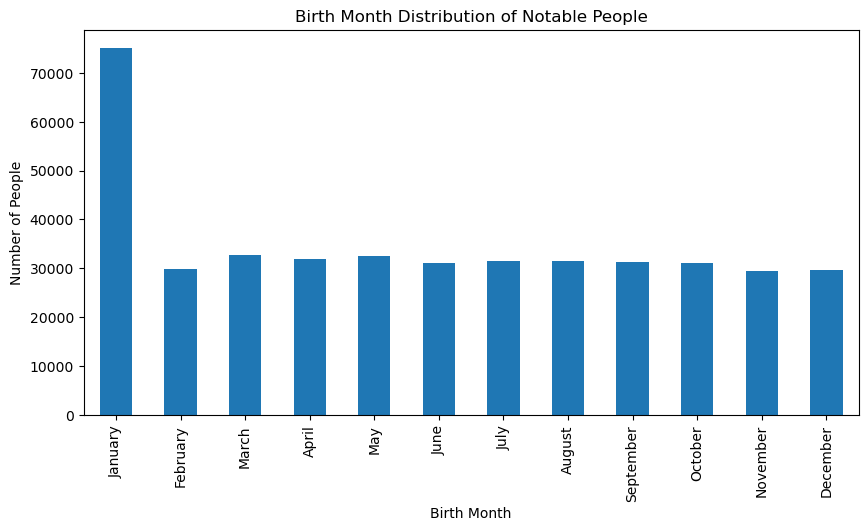

In [15]:
ax = month_counts.plot(kind='bar', figsize=(10, 5))

ax.set_title('Birth Month Distribution of Notable People')
ax.set_xlabel('Birth Month')
ax.set_ylabel('Number of People')

The birth month distribution shows that January has the highest count, more than double the other months. This is unusually high, so I would look into this further before making any conclusions about birth month patterns.

My first assumption is that some birth dates are incomplete or unknown and were defaulted to January.

In [16]:
jan_days = notable.loc[notable['birth_month_name'] == 'January', 'birth_day'].value_counts().sort_index()

jan_days.head()

birth_day
1    44343
2     1082
3     1070
4     1035
5     1063
Name: count, dtype: int64

### Exploration: January 1st birth dates

January 1st appears far more often than any other January day, which suggests that it could be a placeholder date for unknown birthdays. 

I'm curious to see the distribution of Janauary 1st birthdays by year - maybe it's skewed toward ancient/historic figures.

Since birth month patterns is one of the main things I'm analyzing, I want to have clear understanding before moving foward or keeping all of them in my analysis. I may move forward with a filtered version to addressed distortion.

In trying to understand the Jan. 1 birth dates, I found that the timestamps for `date_of_birth` were limited to the years between 1901 and 2015. 

I'll have to limit my analysis to modern notable people and double check the data.

Because of this, I will treat this project as an analysis of modern notable people, not all notable people across history. Any conclusions about birth month patterns should be limited to this dataset.

### Flagging January 1 birthdays

January 1 appears way more often than expected, so I’m treating it as a possible placeholder date instead of assuming every Jan 1 birthday is real.

I’m not dropping these records because some of them are probably valid. Instead, I’m creating a flag so I can keep the data but still control for this issue later.

In [17]:
# Jan 1 is very high, so I want a simple flag I can use later (1 = possible placeholder birthday, 0 = normal birthday)
notable['jan1_flag'] = (
    (notable['birth_month'] == 1) & 
    (notable['birth_day'] == 1)).astype(int)

notable['jan1_flag'].value_counts()

jan1_flag
0    373183
1     44343
Name: count, dtype: int64

In [18]:
# Checking how big this issue is overall before deciding how much it matters
notable['jan1_flag'].value_counts(normalize=True).mul(100).round(2)

jan1_flag
0    89.38
1    10.62
Name: proportion, dtype: float64

In [19]:
# Checking Jan 1 by decade so I can see if this is tied to certain time periods
jan1_decade = notable.groupby('birth_decade')['jan1_flag'].mean().mul(100).round(2)

jan1_decade

C:\Users\cococ\AppData\Local\Temp\ipykernel_38596\628482200.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jan1_decade = notable.groupby('birth_decade')['jan1_flag'].mean().mul(100).round(2)


birth_decade
1900s     9.43
1910s     6.65
1920s     5.90
1930s     7.58
1940s    10.09
1950s    14.06
1960s    14.30
1970s    13.27
1980s     9.57
1990s     5.94
2000s     3.55
2010s    13.85
2020s      NaN
Name: jan1_flag, dtype: float64

In [20]:
# Check sample size by decade so the Jan 1 rate has proper context
decade_check = notable.groupby('birth_decade', observed=True).agg(
    total=('jan1_flag', 'size'),
    jan1_count=('jan1_flag', 'sum'),
    jan1_rate=('jan1_flag', 'mean'))

decade_check['jan1_rate'] = decade_check['jan1_rate'].mul(100).round(2)

decade_check

,total,jan1_count,jan1_rate
birth_decade,,,
1900s,21020,1983,9.43
1910s,21676,1442,6.65
1920s,28655,1690,5.90
1930s,32375,2455,7.58
1940s,48310,4876,10.09
1950s,60401,8495,14.06
1960s,61843,8843,14.30
1970s,58356,7744,13.27
1980s,51599,4937,9.57


In [21]:
# Create a cleaner version for birthday pattern analysis, without likely Jan 1 placeholder dates
df = notable[notable['jan1_flag'] == 0].copy()

df.shape

(373183, 19)

In [22]:
# Confirm Jan 1 placeholder records were removed from the cleaned birthday dataset
df['jan1_flag'].value_counts()

jan1_flag
0    373183
Name: count, dtype: int64

### January birthday distribution without Jan 1

Now that Jan 1 has been flagged as a likely placeholder issue, I’m checking the January birthday distribution again using the cleaned birthday dataset. This gives a clearer view of the actual pattern across the rest of the month.

In [23]:
# Set the month order manually so the plot follows the calendar
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']

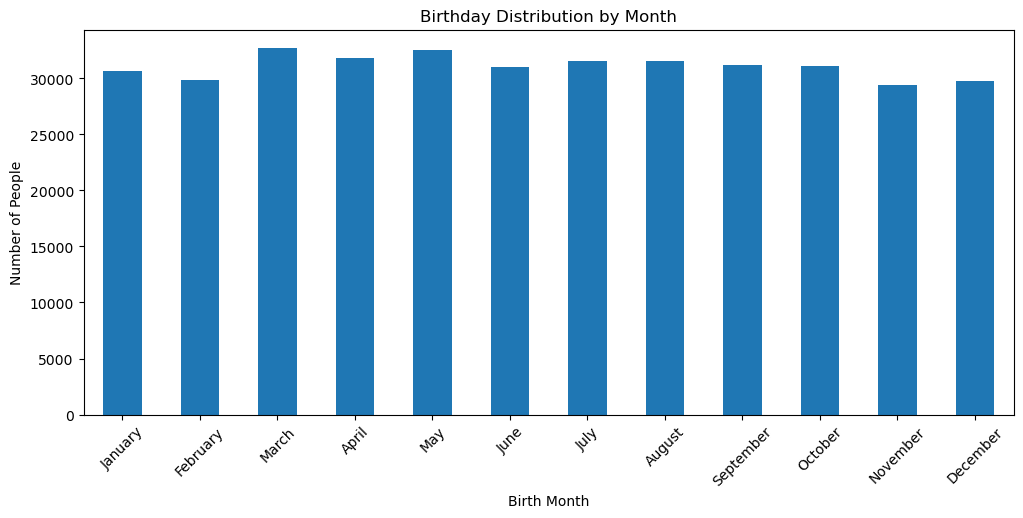

In [24]:
# Count birthdays by month using the cleaned birthday dataset
month_counts = df['birth_month_name'].value_counts().reindex(month_order)

ax = month_counts.plot(kind='bar', figsize=(12, 5))

ax.set_title('Birthday Distribution by Month')
ax.set_xlabel('Birth Month')
ax.set_ylabel('Number of People')

plt.xticks(rotation=45)
plt.show()

In [25]:
# Convert month counts into percentages so the monthly pattern is easier to compare
month_rate = month_counts.div(month_counts.sum()).mul(100).round(2)

month_rate

birth_month_name
January      8.22
February     8.00
March        8.77
April        8.54
May          8.72
June         8.31
July         8.46
August       8.45
September    8.36
October      8.33
November     7.87
December     7.97
Name: count, dtype: float64

## Occupation Analysis

In [26]:
# Rebuild occupation data from cleaned birthday data so Jan 1 placeholders do not skew the patterns
occ = df.copy()

occ['occ_group'] = occ['occupation_groups'].str.split('; ')

occ = occ.explode('occ_group')

occ['occ_group'].value_counts()

occ_group
Arts & Culture        177019
Public Figures        129529
Science & Academia     50282
Sports                 50197
Business               12810
Name: count, dtype: int64

In [27]:
# Compare occupation groups by decade using percentages instead of raw counts
occ_decade = pd.crosstab(
    occ['birth_decade'],
    occ['occ_group'],
    normalize='index').mul(100).round(2)

occ_decade

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
birth_decade,,,,,
1900s,44.15,1.96,32.81,16.10,4.99
1910s,43.01,2.14,34.26,15.42,5.16
1920s,43.26,2.50,31.05,17.50,5.70
1930s,43.14,3.02,28.41,19.22,6.20
1940s,39.94,3.37,33.94,18.18,4.57
1950s,36.60,3.92,39.19,15.32,4.98
1960s,40.11,4.31,38.81,11.14,5.64
1970s,47.07,3.27,32.25,7.35,10.06
1980s,46.43,2.31,19.90,3.26,28.10


### Occupation mix by birth decade

To see how the composition of notable people changes over time, I’m plotting occupation groups by decade as percentages. A 100% stacked bar chart works well here because it shows how each decade is made up across the main occupation categories.

In [28]:
colors = sns.color_palette('Set2', n_colors=occ_decade.shape[1])

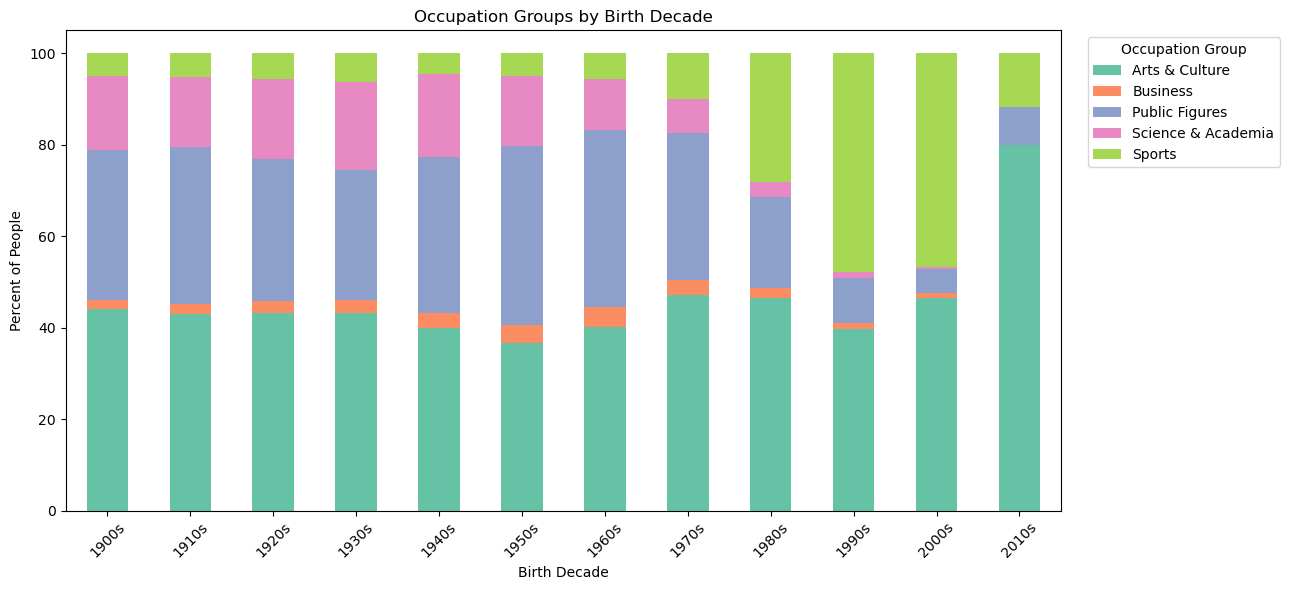

In [29]:
# Plot occupation mix by decade so the shift across time is easier to see
ax = occ_decade.plot(kind='bar', stacked=True, figsize=(13, 6), color=colors)

ax.set_title('Occupation Groups by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

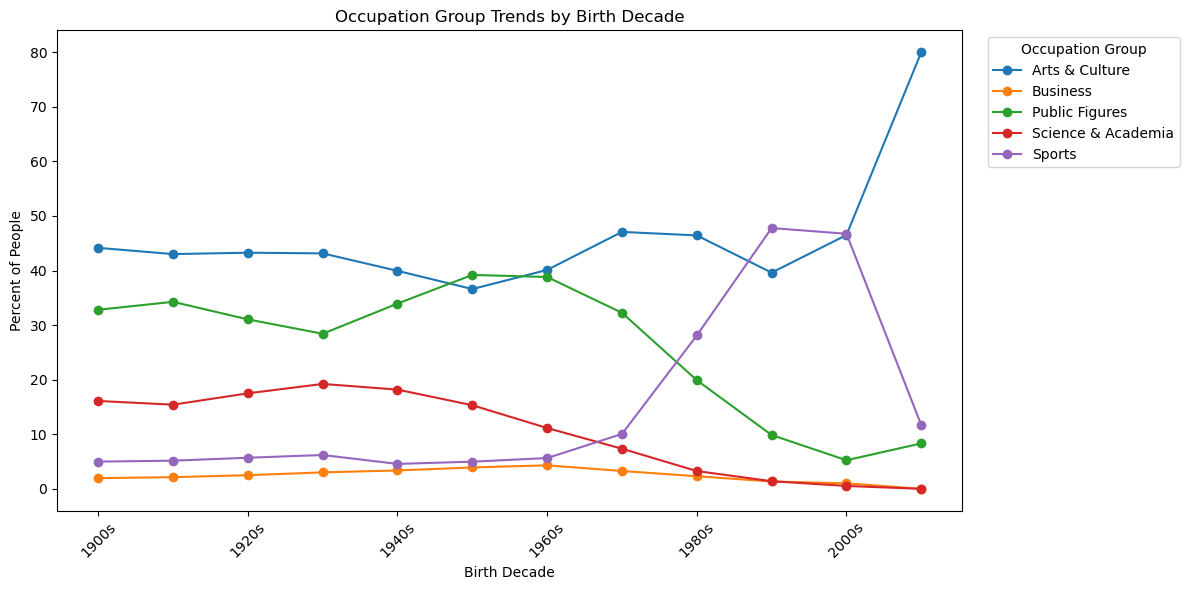

In [30]:
# Use a line chart to make the rise and fall of each occupation group easier to compare
ax = occ_decade.plot(
    kind='line',
    marker='o',
    figsize=(12, 6)
)

ax.set_title('Occupation Group Trends by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Keep only decades with enough records so the trend is not distorted by tiny groups
valid_decades = decade_check[decade_check['total'] >= 1000].index

occ_decade_clean = occ_decade.loc[valid_decades]

occ_decade_clean

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
birth_decade,,,,,
1900s,44.15,1.96,32.81,16.10,4.99
1910s,43.01,2.14,34.26,15.42,5.16
1920s,43.26,2.50,31.05,17.50,5.70
1930s,43.14,3.02,28.41,19.22,6.20
1940s,39.94,3.37,33.94,18.18,4.57
1950s,36.60,3.92,39.19,15.32,4.98
1960s,40.11,4.31,38.81,11.14,5.64
1970s,47.07,3.27,32.25,7.35,10.06
1980s,46.43,2.31,19.90,3.26,28.10


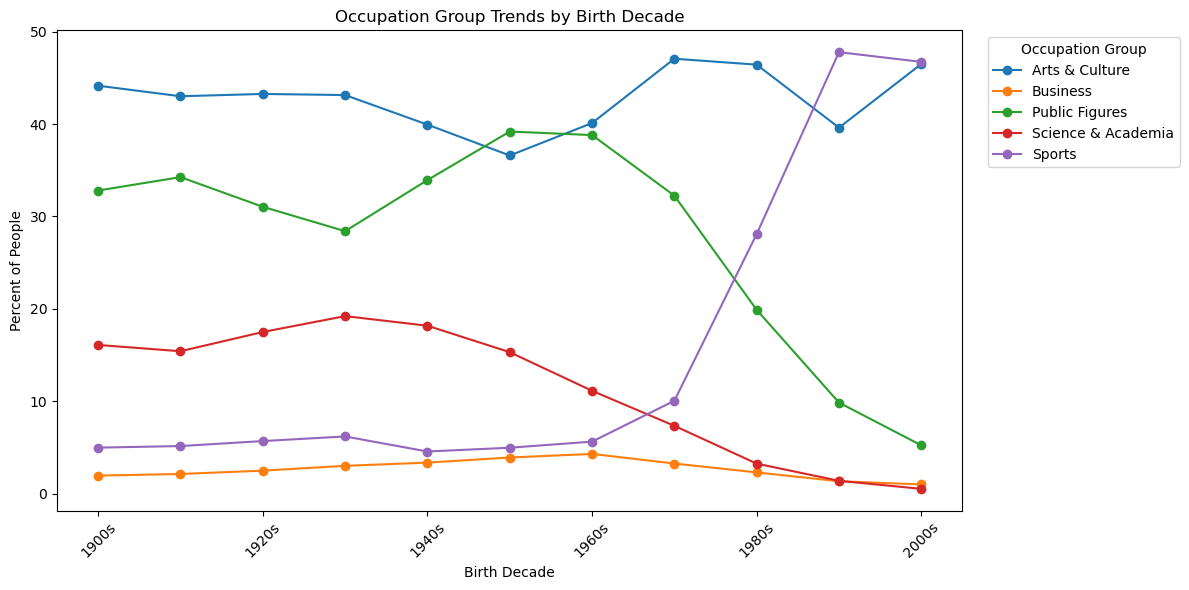

In [32]:
# Replot occupation trends using only decades with enough data
ax = occ_decade_clean.plot(kind='line', marker='o', figsize=(12, 6))

ax.set_title('Occupation Group Trends by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It's interesting to see the changes of notable people occupations over the decades. Arts and culture are consistently high, but there's a huge jump for sports after the 60s. There's also a huge drop in public figures and a steady decline for science and academia. While I'd imagine there's some level of bias in the data set (maybe modern athletes and entertainers are easily and heavily documented), I'm curious what this says about society/culture and its values over time.

## Birth Season Patterns

In [33]:
# Group months into seasons so I can look for broader birthday patterns beyond individual months
season_map = {
    'December': 'Winter',
    'January': 'Winter',
    'February': 'Winter',
    'March': 'Spring',
    'April': 'Spring',
    'May': 'Spring',
    'June': 'Summer',
    'July': 'Summer',
    'August': 'Summer',
    'September': 'Fall',
    'October': 'Fall',
    'November': 'Fall'}

df['birth_season'] = df['birth_month_name'].map(season_map)

df['birth_season'].value_counts()

birth_season
Spring    97127
Summer    94112
Fall      91673
Winter    90271
Name: count, dtype: int64

In [34]:
# Add birth season back after rebuilding occ from the cleaned birthday dataset
occ['birth_season'] = occ['birth_month_name'].map(season_map)

In [35]:
# Convert season counts into percentages so the seasonal pattern is easier to compare
season_rate = df['birth_season'].value_counts(normalize=True).mul(100).round(2)

season_rate

birth_season
Spring    26.03
Summer    25.22
Fall      24.57
Winter    24.19
Name: proportion, dtype: float64

### Birth season patterns

Birthdays look pretty evenly distributed across seasons, which suggests there is not a strong seasonal pattern in the overall dataset. Since the overall pattern looks normal, I want to check whether season looks different within occupation groups.

In [36]:
# Plot birth seasons to see if any part of the year is overrepresented
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

season_rate = season_rate.reindex(season_order)

In [37]:
# Add birth season to the occupation dataframe so I can compare seasons by occupation group
occ['birth_season'] = occ['birth_month_name'].map(season_map)

season_occ = pd.crosstab(
    occ['occ_group'],
    occ['birth_season'],
    normalize='index').mul(100).round(2)

season_occ = season_occ[season_order]

season_occ

birth_season,Winter,Spring,Summer,Fall
occ_group,,,,
Arts & Culture,24.16,26.12,25.05,24.67
Business,23.75,25.60,25.98,24.68
Public Figures,23.95,25.81,25.54,24.70
Science & Academia,23.94,26.19,25.06,24.81
Sports,24.92,26.17,25.10,23.81


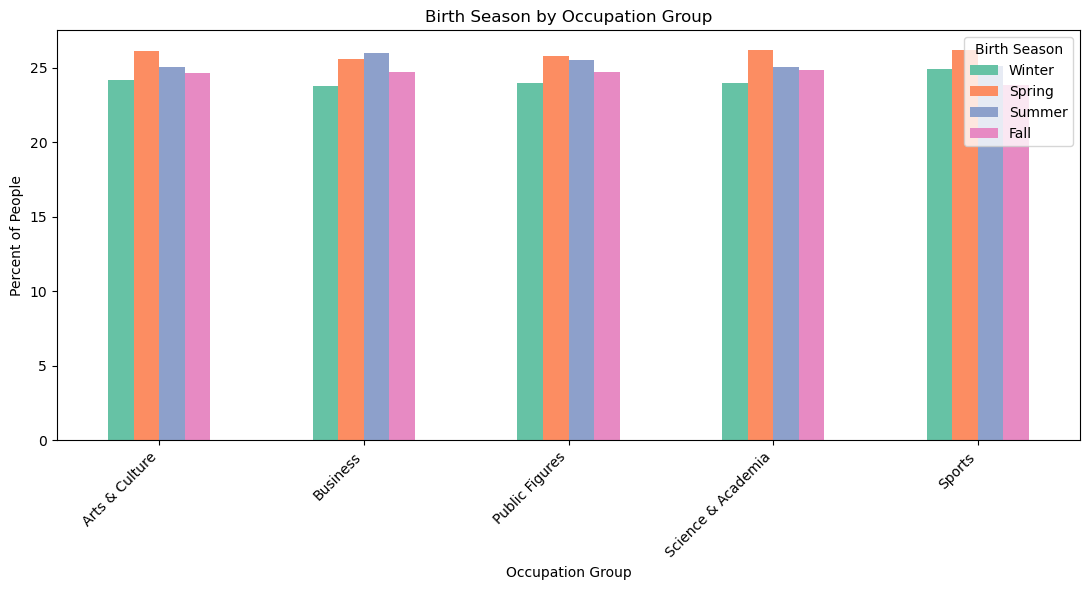

In [38]:
colors = sns.color_palette('Set2', n_colors=season_occ.shape[1])

# Plot birth season by occupation group to compare patterns across fields
ax = season_occ.plot(kind='bar', figsize=(11, 6), color=colors)

ax.set_title('Birth Season by Occupation Group')
ax.set_xlabel('Occupation Group')
ax.set_ylabel('Percent of People')
ax.legend(title='Birth Season')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
# Check birth month patterns by occupation group without going too deep into seasonality
month_occ = pd.crosstab(
    occ['occ_group'],
    occ['birth_month_name'],
    normalize='index'
).mul(100).round(2)

month_occ = month_occ[month_order]

month_occ

birth_month_name,January,February,March,April,May,June,July,August,September,October,November,December
occ_group,,,,,,,,,,,,
Arts & Culture,8.09,7.93,8.83,8.47,8.83,8.26,8.44,8.35,8.32,8.36,7.98,8.15
Business,8.04,8.05,8.70,8.25,8.64,8.46,8.54,8.98,8.43,8.31,7.93,7.66
Public Figures,8.11,7.87,8.72,8.50,8.59,8.47,8.53,8.54,8.39,8.39,7.92,7.97
Science & Academia,8.05,8.06,8.61,8.62,8.96,8.21,8.39,8.46,8.46,8.45,7.90,7.83
Sports,9.01,8.43,8.88,8.76,8.54,8.29,8.40,8.41,8.44,7.93,7.44,7.47


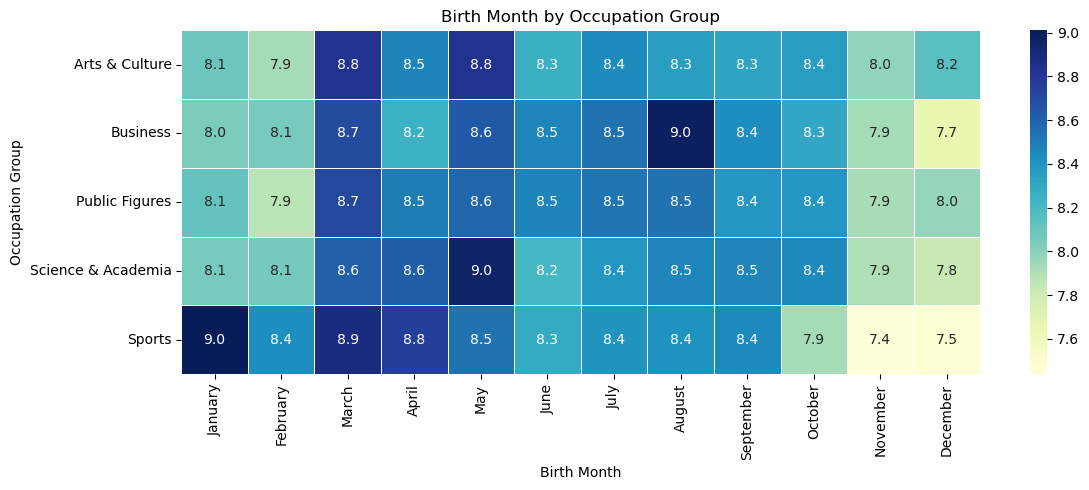

In [40]:
# Use a heatmap because the month differences are subtle and easier to read by color
plt.figure(figsize=(12, 5))

sns.heatmap(
    month_occ,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5)

plt.title('Birth Month by Occupation Group')
plt.xlabel('Birth Month')
plt.ylabel('Occupation Group')

plt.tight_layout()
plt.show()

### Occupation by Country

In [41]:
# Use top 20 countries so the chart is readable and based on stronger sample sizes
top20 = notable['country_of_birth'].value_counts().head(20).index

country_occ = notable[notable['country_of_birth'].isin(top20)].copy()

country_occ['occ_group'] = country_occ['occupation_groups'].str.split('; ')

country_occ = country_occ.explode('occ_group')

In [42]:
# Convert occupation counts to percentages so countries can be compared fairly
country_mix = pd.crosstab(
    country_occ['country_of_birth'],
    country_occ['occ_group'],
    normalize='index').mul(100).round(2)

country_mix = country_mix.loc[top20]

country_mix.head()

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
country_of_birth,,,,,
United States,39.18,3.51,21.32,8.30,27.68
Germany,41.91,2.09,35.30,15.78,4.91
Italy,40.69,2.91,42.90,10.10,3.40
France,49.51,3.86,27.34,14.81,4.48
Spain,45.28,3.19,31.48,17.06,2.99


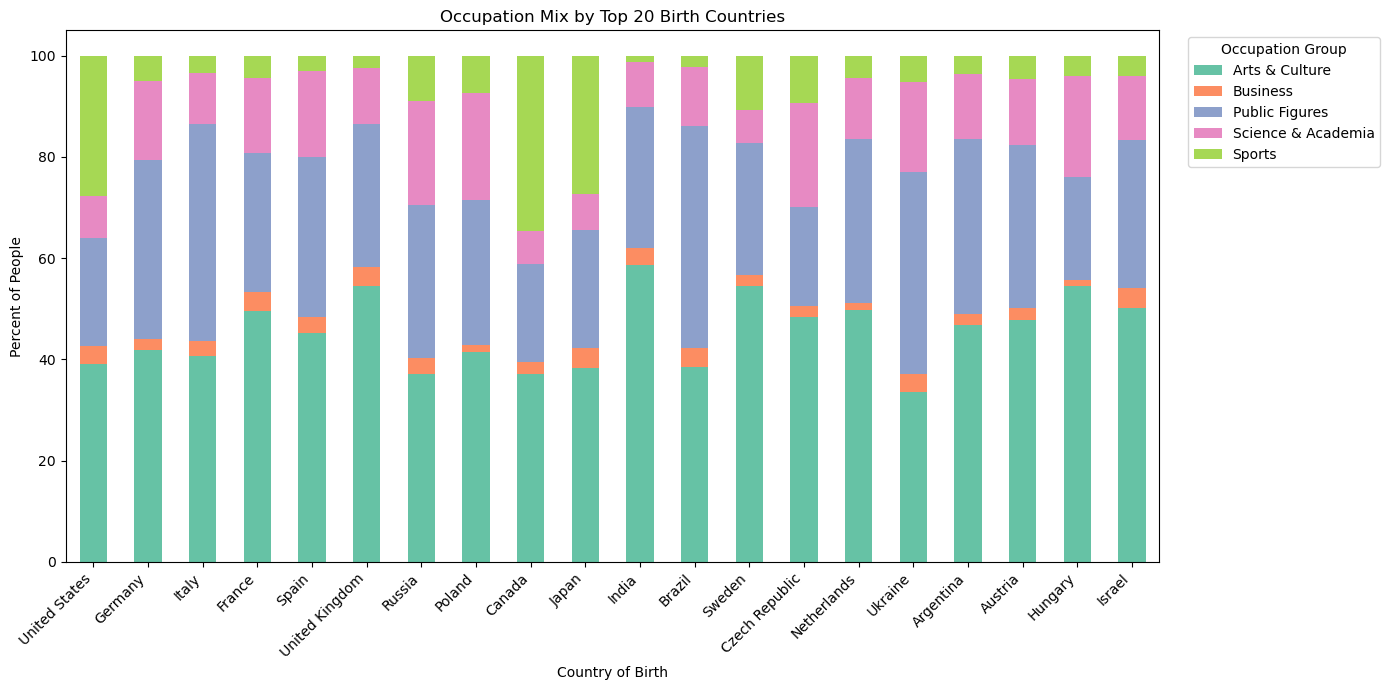

In [43]:
# Plot occupation breakdown by country to compare each country's notable people mix
colors = sns.color_palette('Set2', n_colors=country_mix.shape[1])

ax = country_mix.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)

ax.set_title('Occupation Mix by Top 20 Birth Countries')
ax.set_xlabel('Country of Birth')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
# Focus on a few countries I want to compare more closely
focus_countries = ['Ireland', 'Philippines', 'Poland', 'Samoa']

focus = notable[notable['country_of_birth'].isin(focus_countries)].copy()

focus['country_of_birth'].value_counts()

country_of_birth
Poland         12987
Philippines     1448
Ireland         1211
Samoa             33
Name: count, dtype: Int64

In [45]:
# Split occupation groups so people with multiple categories count in each relevant group
focus['occ_group'] = focus['occupation_groups'].str.split('; ')

focus = focus.explode('occ_group')

focus[['country_of_birth', 'occ_group']].head()

,country_of_birth,occ_group
9,Ireland,Public Figures
90,Poland,Arts & Culture
187,Poland,Arts & Culture
239,Poland,Arts & Culture
241,Poland,Public Figures


In [46]:
# Compare occupation mix across the selected countries using percentages
focus_mix = pd.crosstab(
    focus['country_of_birth'],
    focus['occ_group'],
    normalize='index').mul(100).round(2)

focus_mix

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
country_of_birth,,,,,
Ireland,44.08,3.01,43.86,7.61,1.43
Philippines,39.03,3.90,42.01,4.09,10.97
Poland,41.48,1.32,28.73,21.04,7.43
Samoa,27.78,5.56,52.78,8.33,5.56


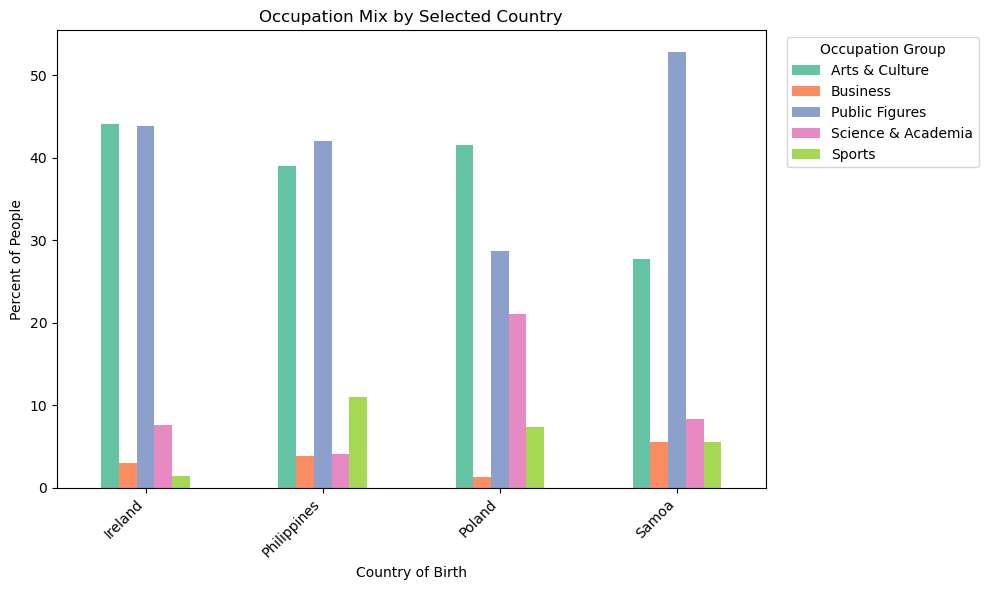

In [47]:
# Plot selected countries so the occupation differences are easier to see
colors = sns.color_palette('Set2', n_colors=focus_mix.shape[1])

ax = focus_mix.plot(kind='bar', figsize=(10, 6), color=colors)

ax.set_title('Occupation Mix by Selected Country')
ax.set_xlabel('Country of Birth')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Actor/Actress Birth Month Patterns

In [49]:
# Find actors/actresses in the cleaned birthday data so Jan 1 placeholders do not skew the month pattern
actors = df[
    df['occupations'].str.contains('actor|actress', case=False, na=False)].copy()

actors[['label', 'occupations', 'birth_month_name', 'birth_day']].head()

,label,occupations,birth_month_name,birth_day
1,Henk Rigters,actor; stage actor; director; television actor...,October,6
7,Jörg Hube,actor; stage actor; film director; television ...,November,22
16,Bud Lee,pornographic actor; film director,September,30
28,Fernando Carrillo,singer; pianist; model; television actor; film...,January,6
35,Pyotr Buslov,screenwriter; actor; film director,June,1


In [50]:
# Count actor/actress birthdays by month
actor_months = actors['birth_month_name'].value_counts().reindex(month_order)

actor_months

birth_month_name
January      5498
February     5418
March        6006
April        5447
May          5912
June         5494
July         5812
August       5717
September    5786
October      5716
November     5559
December     5432
Name: count, dtype: int64

In [51]:
# Convert to percentages so the actor/actress pattern is easier to compare across months
actor_month_rate = actor_months.div(actor_months.sum()).mul(100).round(2)

actor_month_rate

birth_month_name
January      8.11
February     7.99
March        8.86
April        8.03
May          8.72
June         8.10
July         8.57
August       8.43
September    8.53
October      8.43
November     8.20
December     8.01
Name: count, dtype: float64

In [53]:
# Compare actor/actress birth months to the overall cleaned birthday pattern
actor_compare = pd.DataFrame({
    'All People': month_rate,
    'Actors/Actresses': actor_month_rate})

actor_compare['Difference'] = actor_compare['Actors/Actresses'] - actor_compare['All People']

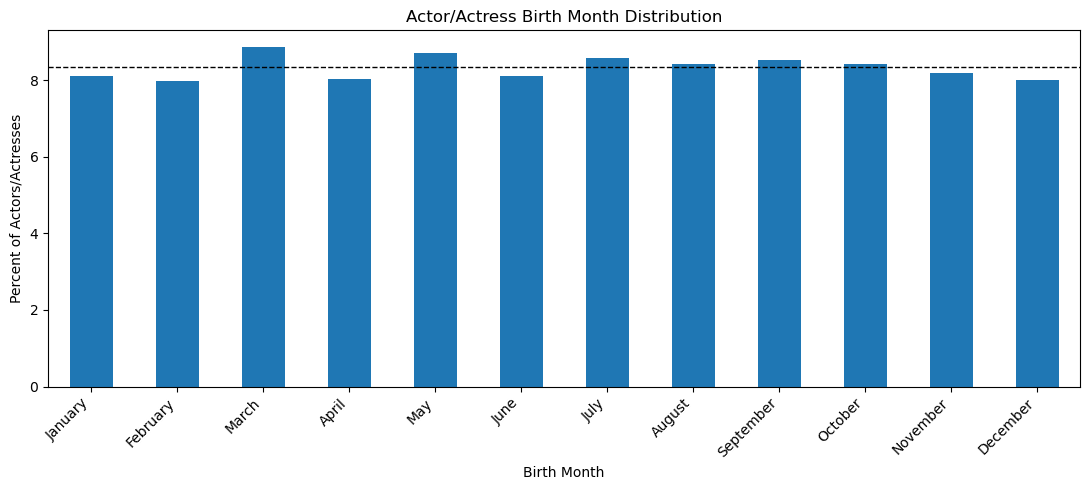

In [54]:
# Plot actor/actress birth months against the expected average month share
ax = actor_month_rate.plot(kind='bar', figsize=(11, 5))

ax.axhline(100 / 12, color='black', linewidth=1, linestyle='--')

ax.set_title('Actor/Actress Birth Month Distribution')
ax.set_xlabel('Birth Month')
ax.set_ylabel('Percent of Actors/Actresses')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exploring Science & Academia 

In [55]:
# Use cleaned birthday data so the analysis stays consistent after removing Jan 1 placeholders
science = df[
    df['occupation_groups'].str.contains('Science & Academia', case=False, na=False)].copy()

science['country_of_birth'].value_counts().head(20)

country_of_birth
United States     6388
Germany           3883
Russia            3278
Poland            2684
France            2679
Spain             2497
Czech Republic    1996
Italy             1875
United Kingdom    1725
Ukraine           1520
Brazil            1153
Hungary           1071
Netherlands        981
India              752
Romania            730
Argentina          705
Austria            632
Japan              628
Canada             592
Switzerland        592
Name: count, dtype: Int64

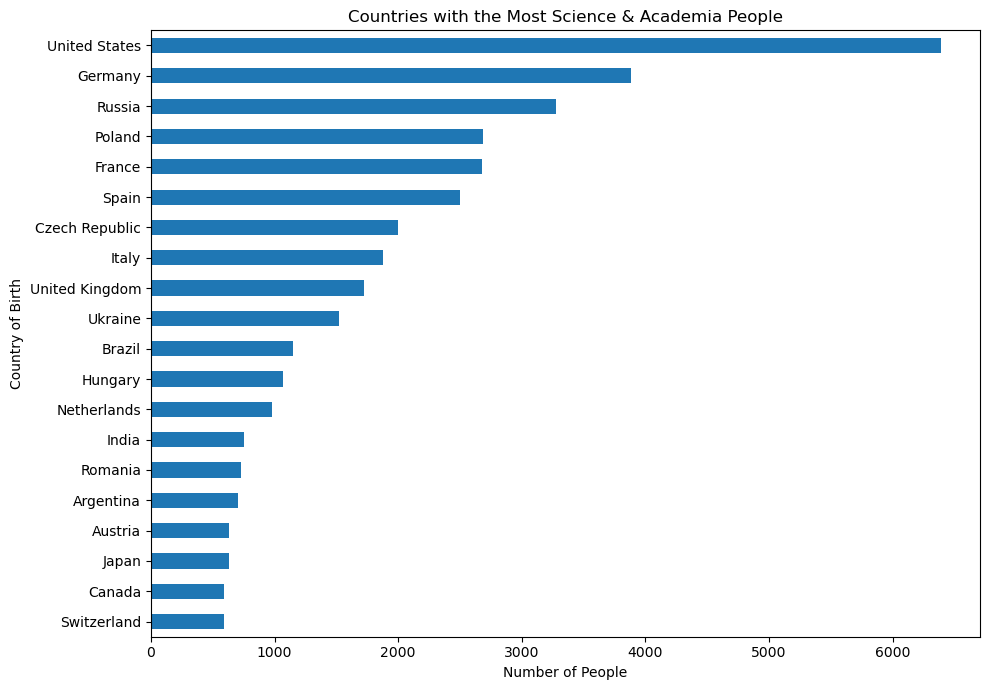

In [56]:
# Plot countries with the highest number of Science & Academia people
science_countries = science['country_of_birth'].value_counts().head(20)

ax = science_countries.sort_values().plot(kind='barh', figsize=(10, 7))

ax.set_title('Countries with the Most Science & Academia People')
ax.set_xlabel('Number of People')
ax.set_ylabel('Country of Birth')

plt.tight_layout()
plt.show()

In [57]:
# Check the most common science-related occupations before grouping them into broader fields
science['occupations'].value_counts().head(30)

occupations
politician; economist                        1367
historian                                    1330
economist                                    1265
scientist                                    1238
mathematician; university teacher             981
physician                                     891
physicist                                     865
engineer                                      859
physician; politician                         828
mathematician                                 779
teacher; politician                           677
chemist                                       554
engineer; politician                          549
teacher                                       534
historian; university teacher                 492
philosopher                                   425
economist; university teacher                 425
physicist; university teacher                 421
chemist; university teacher                   310
psychologist                          

In [58]:
# Check which countries show up most often for each science-related profession
science_fields = ['physicist', 'chemist', 'mathematician', 'biologist', 'engineer', 'physician', 'economist', 'historian', 'psychologist', 'computer scientist']

for field in science_fields:
    print(f'\nTop countries for {field}:')
    
    field_df = science[
        science['occupations'].str.contains(field, case=False, na=False)]
    
    print(field_df['country_of_birth'].value_counts().head(10))


Top countries for physicist:
country_of_birth
United States     704
Germany           402
Russia            315
France            182
United Kingdom    170
Italy             148
Poland            146
Ukraine           116
India              96
Czech Republic     94
Name: count, dtype: Int64

Top countries for chemist:
country_of_birth
United States     428
Germany           311
Poland            126
Russia            123
United Kingdom    123
Spain              85
Czech Republic     69
France             66
Hungary            56
Japan              53
Name: count, dtype: Int64

Top countries for mathematician:
country_of_birth
United States     590
Germany           466
Russia            350
France            213
United Kingdom    171
Poland            133
Ukraine           123
Italy             118
Hungary            98
Romania            87
Name: count, dtype: Int64

Top countries for biologist:
country_of_birth
United States     296
Germany           137
France             89
United

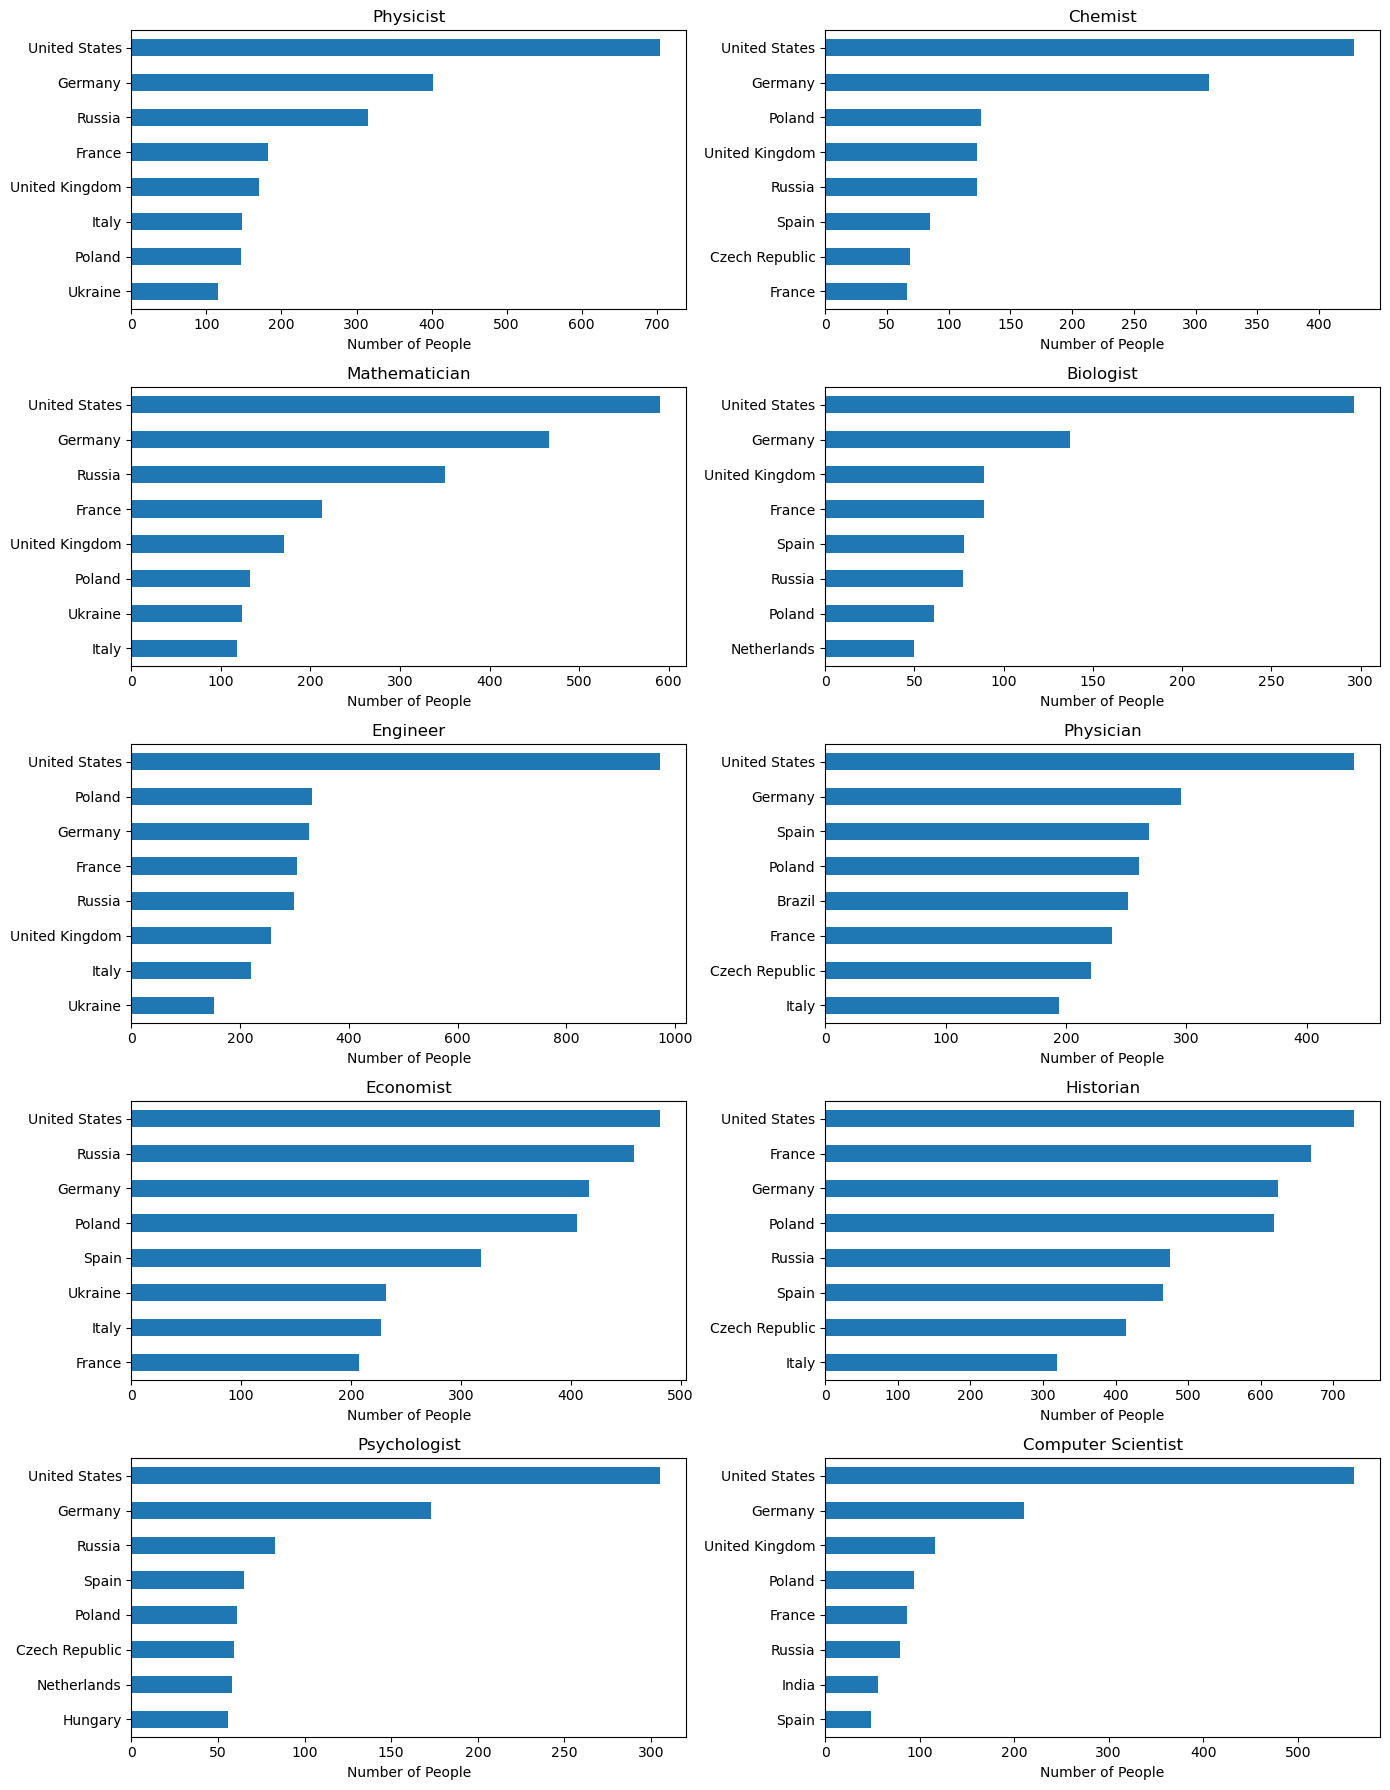

In [59]:
# Create subplots so I can compare top countries across science fields in one view

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, field in zip(axes, science_fields):
    field_df = science[
        science['occupations'].str.contains(field, case=False, na=False)
    ]

    top_countries = field_df['country_of_birth'].value_counts().head(8).sort_values()

    top_countries.plot(kind='barh', ax=ax)

    ax.set_title(field.title())
    ax.set_xlabel('Number of People')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Exploring Arts & Culture

In [60]:
# Use cleaned birthday data and focus only on Arts & Culture records
arts = df[
    df['occupation_groups'].str.contains('Arts & Culture', case=False, na=False)].copy()

arts['occupations'].value_counts().head(30)

occupations
actor                                               12060
singer                                               7302
writer                                               5874
painter                                              4564
actor; film actor                                    2981
musician                                             2717
actor; television actor; film actor                  2427
actor; television actor                              2362
writer; journalist                                   1864
composer                                             1786
actor; singer                                        1778
writer; poet                                         1496
architect                                            1459
actor; stage actor; television actor; film actor     1395
photographer                                         1365
sculptor                                             1335
screenwriter; film director                          1258
ac

In [61]:
# Check the most common arts/culture roles for reference
arts['occupations'].value_counts().head(30)


occupations
actor                                               12060
singer                                               7302
writer                                               5874
painter                                              4564
actor; film actor                                    2981
musician                                             2717
actor; television actor; film actor                  2427
actor; television actor                              2362
writer; journalist                                   1864
composer                                             1786
actor; singer                                        1778
writer; poet                                         1496
architect                                            1459
actor; stage actor; television actor; film actor     1395
photographer                                         1365
sculptor                                             1335
screenwriter; film director                          1258
ac

In [63]:
# Group creative roles with simple keyword matches so the categories are easier to build
arts_types = {
    'Actor': 'actor',
    'Model': 'model|beauty queen',
    'Musician': 'singer|musician|composer|rapper|songwriter|guitarist|pianist',
    'DJ': 'disc jockey|dj',
    'photo/cinema': 'photographer|cinematographer',
    'Visual Artist': 'painter|artist|illustrator|cartoonist|sculptor',
    'Writer': 'writer|novelist|poet|author|journalist|screenwriter',
    'Director/Producer': 'director|producer'}

In [64]:
# Create one row per person per art type so people with multiple creative roles can count in each group
arts_long = []

for art_type, pattern in arts_types.items():
    matches = arts[arts['occupations'].str.contains(pattern, case=False, na=False)].copy()
    matches['arts_type'] = art_type
    arts_long.append(matches)

arts_long = pd.concat(arts_long, ignore_index=True)

arts_long['arts_type'].value_counts()

arts_type
Writer               70937
Actor                67678
Musician             54727
Director/Producer    28256
Visual Artist        23461
Model                 6755
photo/cinema          5963
DJ                    1295
Name: count, dtype: int64

In [65]:
# For each creative type, check which countries show up the most
for art_type in arts_long['arts_type'].unique():
    print(f'\nTop countries for {art_type}:')
    
    top_countries = (
        arts_long[arts_long['arts_type'] == art_type]['country_of_birth']
        .value_counts()
        .head(10))
    
    print(top_countries)


Top countries for Actor:
country_of_birth
United States     15276
United Kingdom     3676
India              3085
Germany            3077
Italy              2900
France             2837
Japan              2086
Russia             1909
Poland             1872
Spain              1762
Name: count, dtype: Int64

Top countries for Model:
country_of_birth
United States     1689
India              506
South Korea        368
Japan              357
United Kingdom     334
Brazil             217
France             186
Italy              178
Germany            171
Indonesia          140
Name: count, dtype: Int64

Top countries for Musician:
country_of_birth
United States     11868
United Kingdom     3422
Germany            2480
Italy              2042
France             1923
Russia             1591
Spain              1489
South Korea        1484
Sweden             1381
Brazil             1351
Name: count, dtype: Int64

Top countries for DJ:
country_of_birth
United States     316
United Kingdom    

In [66]:
# Focus on 1901 onward so the trend is easier to compare across modern decades
arts_modern = arts_long[arts_long['birth_year'] >= 1901].copy()

arts_modern['birth_decade'] = (arts_modern['birth_year'] // 10 * 10).astype(int)

arts_modern[['label', 'arts_type', 'birth_year', 'birth_decade']].head()

,label,arts_type,birth_year,birth_decade
0,Henk Rigters,Actor,1915,1910
1,Jörg Hube,Actor,1943,1940
2,Bud Lee,Actor,1955,1950
3,Fernando Carrillo,Actor,1965,1960
4,Pyotr Buslov,Actor,1976,1970


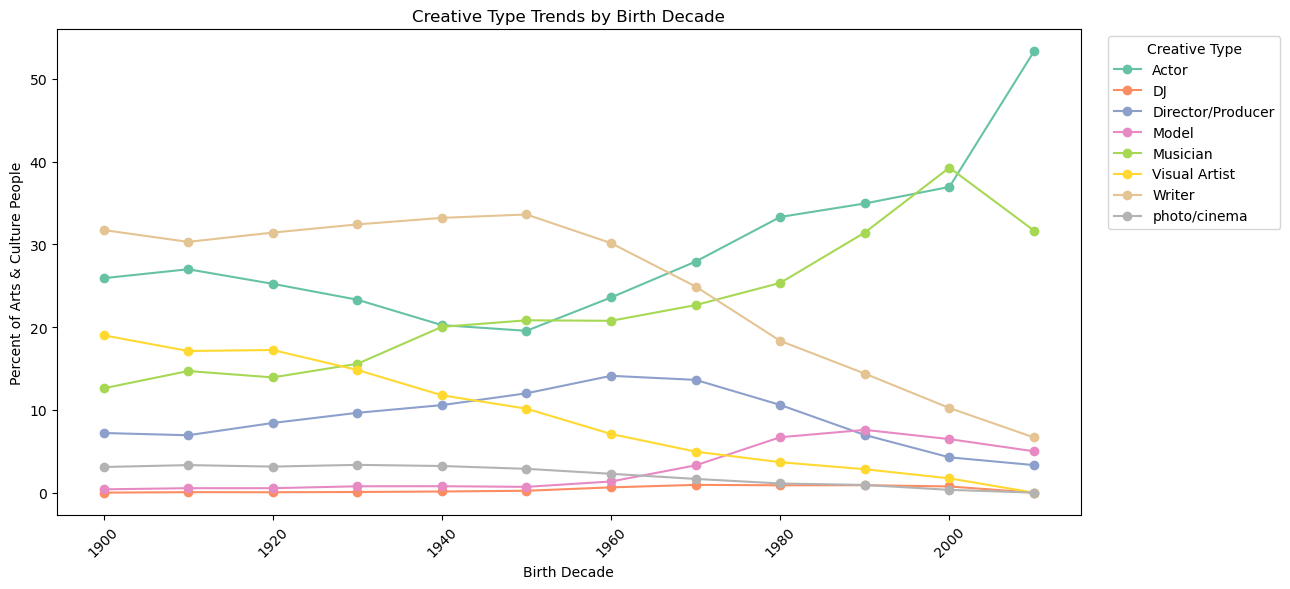

In [67]:
# Compare creative type representation by decade using percentages instead of raw counts
arts_decade = pd.crosstab(
    arts_modern['birth_decade'],
    arts_modern['arts_type'],
    normalize='index').mul(100).round(2)

# Plot how creative professions changed across birth decades
colors = sns.color_palette('Set2', n_colors=arts_decade.shape[1])

ax = arts_decade.plot(kind='line', marker='o', figsize=(13, 6), color=colors)

ax.set_title('Creative Type Trends by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of Arts & Culture People')
ax.legend(title='Creative Type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
# Compare birth month patterns across creative types
art_month = pd.crosstab(
    arts_long['arts_type'],
    arts_long['birth_month_name'],
    normalize='index').mul(100).round(2)

art_month = art_month[month_order]


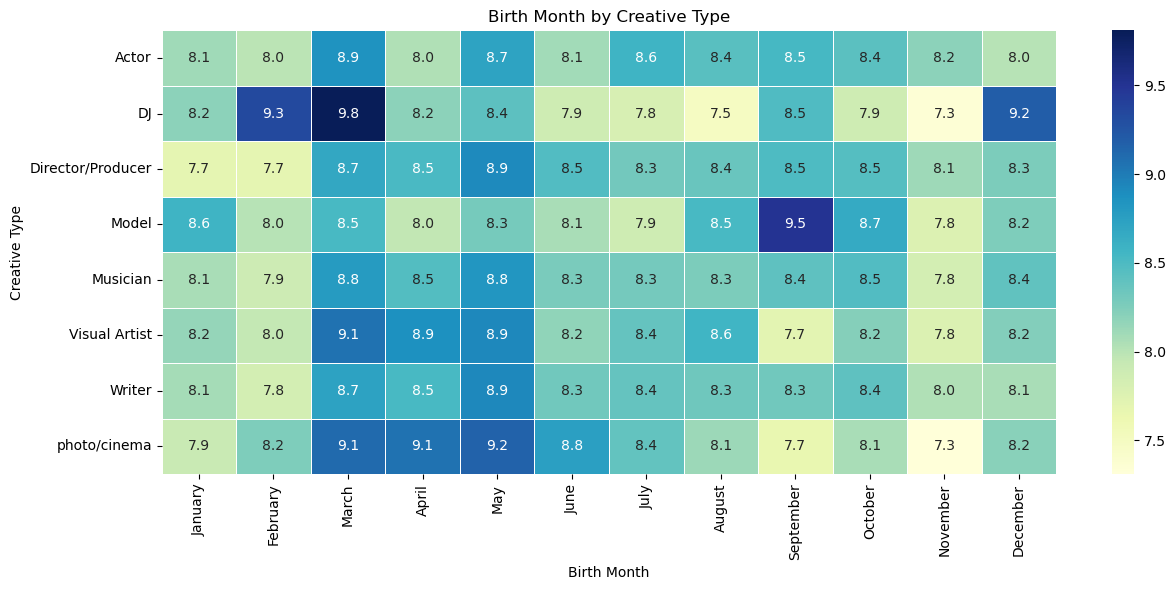

In [69]:
# Use a heatmap because small month differences are easier to read by color
plt.figure(figsize=(13, 6))

sns.heatmap(
    art_month,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5)

plt.title('Birth Month by Creative Type')
plt.xlabel('Birth Month')
plt.ylabel('Creative Type')

plt.tight_layout()
plt.show()

In [70]:
# Group creative birth months into seasons so the pattern is easier to read than 12 separate months
arts_long['birth_season'] = arts_long['birth_month_name'].map(season_map)

art_season = pd.crosstab(
    arts_long['arts_type'],
    arts_long['birth_season'],
    normalize='index').mul(100).round(2)

art_season = art_season[season_order]

art_season

birth_season,Winter,Spring,Summer,Fall
arts_type,,,,
Actor,24.12,25.62,25.11,25.16
DJ,26.72,26.41,23.17,23.71
Director/Producer,23.66,26.12,25.15,25.07
Model,24.83,24.78,24.47,25.92
Musician,24.36,26.09,24.82,24.72
Visual Artist,24.33,26.85,25.11,23.71
Writer,24.00,26.20,25.03,24.77
photo/cinema,24.37,27.32,25.27,23.04


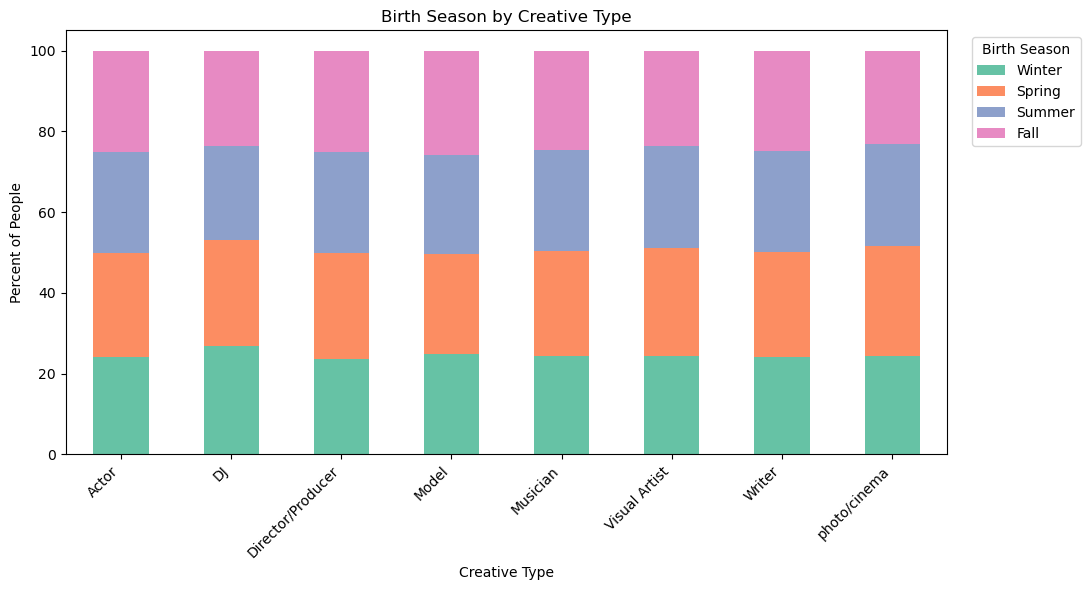

In [72]:
# Plot seasonal birthday patterns by creative type
colors = sns.color_palette('Set2', n_colors=art_season.shape[1])

ax = art_season.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    color=colors)

ax.set_title('Birth Season by Creative Type')
ax.set_xlabel('Creative Type')
ax.set_ylabel('Percent of People')
ax.legend(title='Birth Season', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Gender Exploration

In [73]:
# Build one clean dataframe for gender/profession analysis so I can reuse it later
gender_df = df.copy()

gender_df['occ_group'] = gender_df['occupation_groups'].str.split('; ')

gender_df = gender_df.explode('occ_group')


In [74]:
# Count gender groups within each occupation group
gender_counts = pd.crosstab(
    gender_df['occ_group'],
    gender_df['gender_group'])

gender_counts

gender_group,female,male,non-binary / gender diverse,trans,undisclosed
occ_group,,,,,
Arts & Culture,57231,119219,253,315,1
Business,1901,10893,1,15,0
Public Figures,28657,100691,39,141,1
Science & Academia,8573,41644,10,54,1
Sports,5090,45096,4,7,0


In [75]:
# Create focused gender comparison tables for cleaner plotting
mf_counts = gender_counts[['male', 'female']]

nb_trans_counts = gender_counts[['non-binary / gender diverse', 'trans']]

all_gender_counts = gender_counts[['male', 'female', 'non-binary / gender diverse', 'trans']]

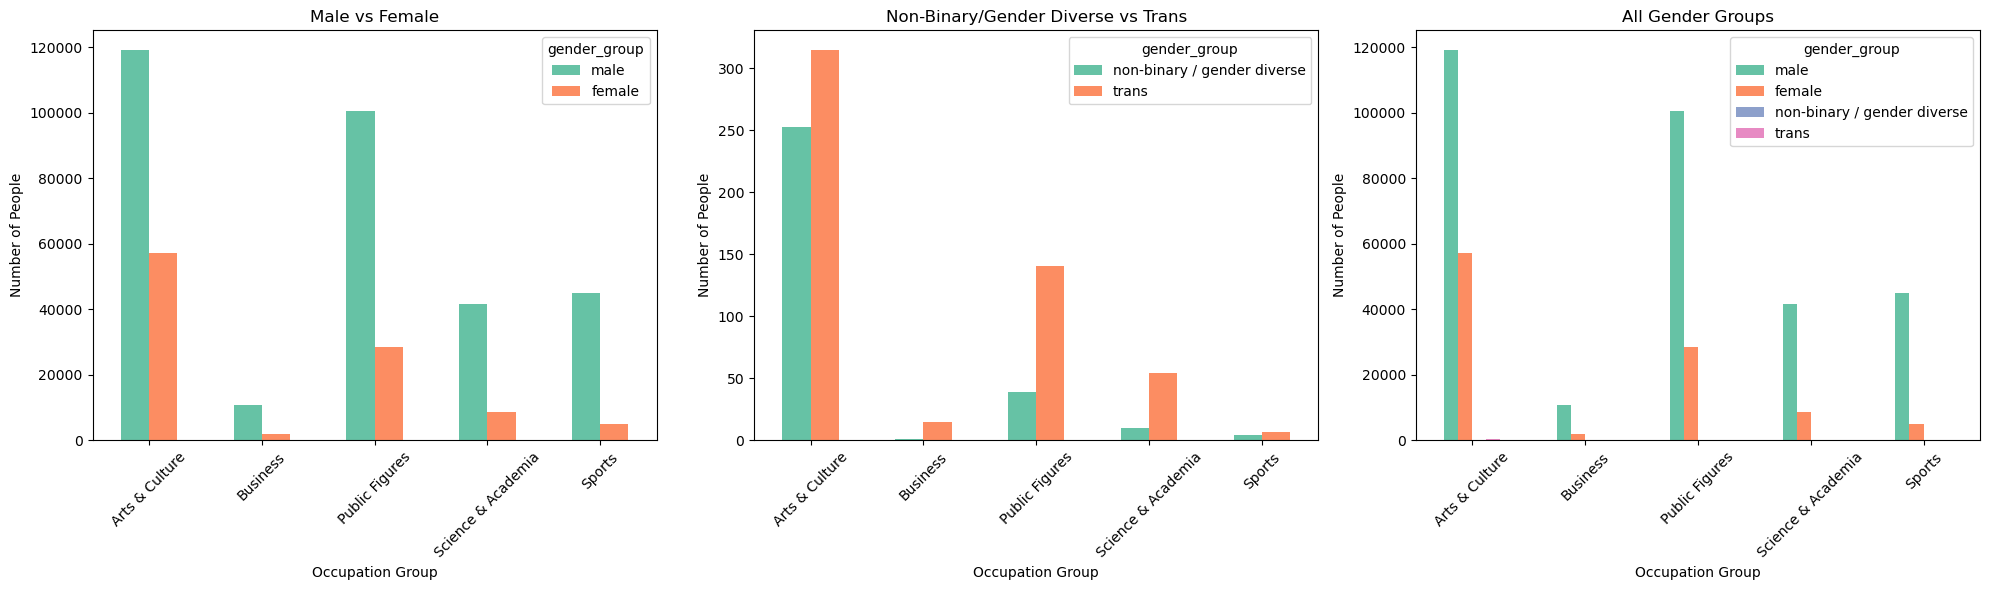

In [76]:
# Plot gender comparisons separately so the smaller groups are not hidden by the larger male/female counts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

mf_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 2))
axes[0].set_title('Male vs Female')
axes[0].set_xlabel('Occupation Group')
axes[0].set_ylabel('Number of People')

nb_trans_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 2))
axes[1].set_title('Non-Binary/Gender Diverse vs Trans')
axes[1].set_xlabel('Occupation Group')
axes[1].set_ylabel('Number of People')

all_gender_counts.plot(kind='bar', ax=axes[2], color=sns.color_palette('Set2', 4))
axes[2].set_title('All Gender Groups')
axes[2].set_xlabel('Occupation Group')
axes[2].set_ylabel('Number of People')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [77]:
# Convert counts to percentages so occupation groups can be compared fairly
gender_pct = pd.crosstab(
    gender_df['occ_group'],
    gender_df['gender_group'],
    normalize='index').mul(100).round(2)

gender_pct

gender_group,female,male,non-binary / gender diverse,trans,undisclosed
occ_group,,,,,
Arts & Culture,32.33,67.35,0.14,0.18,0.0
Business,14.84,85.04,0.01,0.12,0.0
Public Figures,22.12,77.74,0.03,0.11,0.0
Science & Academia,17.05,82.82,0.02,0.11,0.0
Sports,10.14,89.84,0.01,0.01,0.0


In [78]:
# Create focused percentage tables for cleaner gender comparison plots
mf_pct = gender_pct[['male', 'female']]

nb_trans_pct = gender_pct[['non-binary / gender diverse', 'trans']]

all_gender_pct = gender_pct[['male', 'female', 'non-binary / gender diverse', 'trans']]

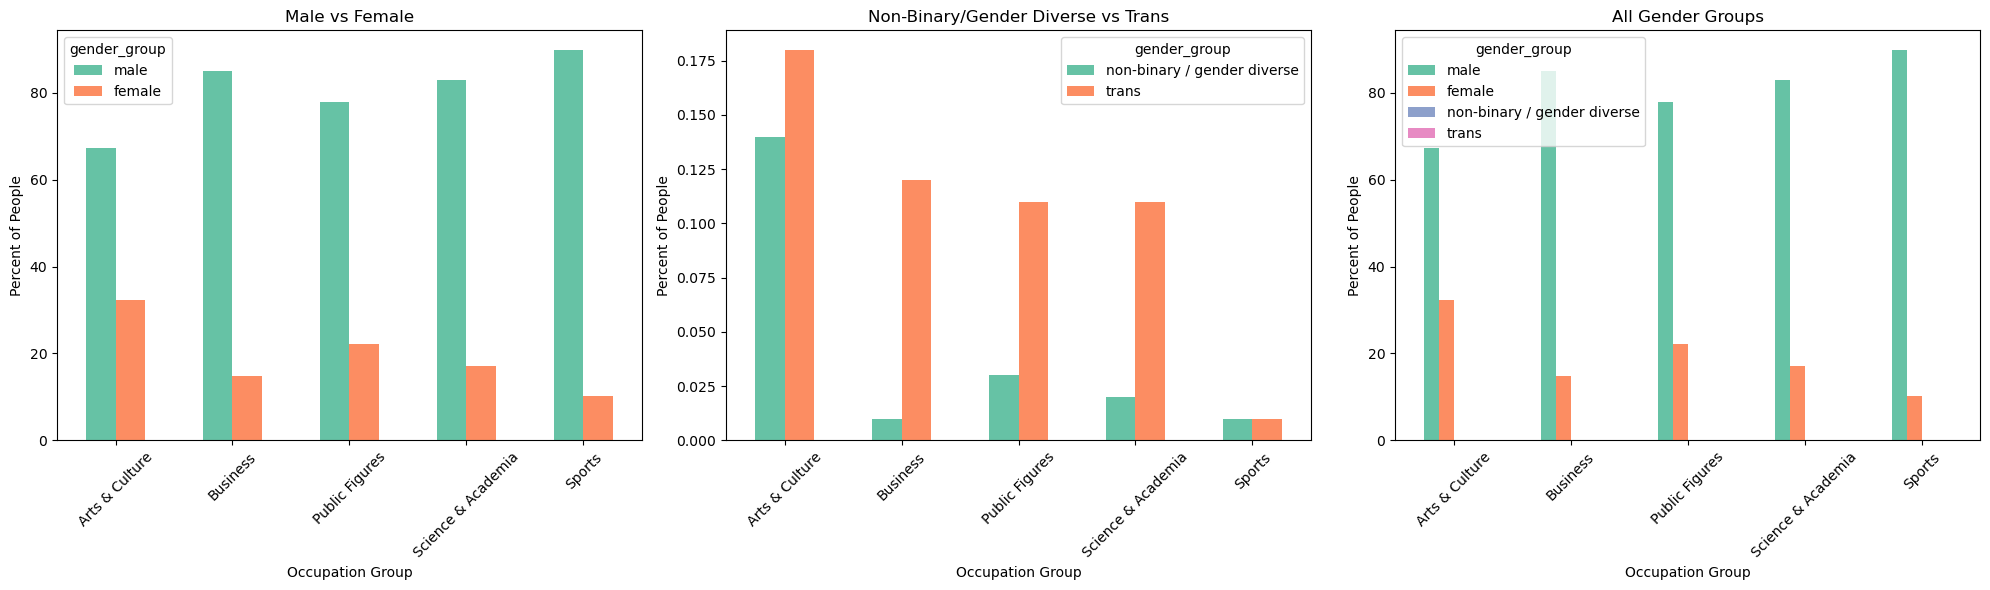

In [79]:
# Plot gender percentages so the smaller occupation groups do not get hidden by raw counts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

mf_pct.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 2))
axes[0].set_title('Male vs Female')
axes[0].set_ylabel('Percent of People')

nb_trans_pct.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 2))
axes[1].set_title('Non-Binary/Gender Diverse vs Trans')
axes[1].set_ylabel('Percent of People')

all_gender_pct.plot(kind='bar', ax=axes[2], color=sns.color_palette('Set2', 4))
axes[2].set_title('All Gender Groups')
axes[2].set_ylabel('Percent of People')

for ax in axes:
    ax.set_xlabel('Occupation Group')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [80]:
# Compare gender representation by birth decade using percentages instead of raw counts
gender_decade = pd.crosstab(
    gender_df['birth_decade'],
    gender_df['gender_group'],
    normalize='index').mul(100).round(2)

# Keep the main gender groups in a consistent order for plotting
gender_cols = ['male', 'female', 'non-binary / gender diverse', 'trans']

gender_decade = gender_decade[gender_cols]

gender_decade

gender_group,male,female,non-binary / gender diverse,trans
birth_decade,,,,
1900s,84.01,15.97,0.00,0.02
1910s,82.74,17.25,0.00,0.01
1920s,82.93,17.04,0.00,0.03
1930s,83.41,16.55,0.00,0.04
1940s,80.75,19.18,0.01,0.06
1950s,78.90,20.98,0.02,0.10
1960s,74.38,25.42,0.05,0.15
1970s,68.96,30.82,0.07,0.14
1980s,65.05,34.51,0.18,0.26


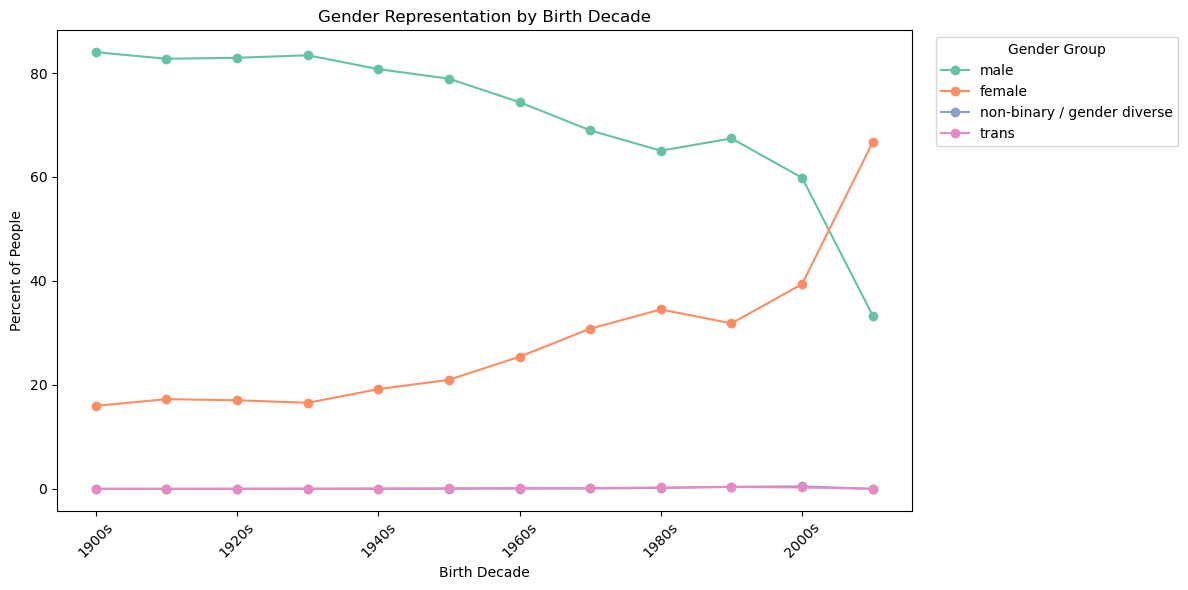

In [81]:
# Plot gender representation over time to see how the dataset changes by birth decade
colors = sns.color_palette('Set2', n_colors=gender_decade.shape[1])

ax = gender_decade.plot(kind='line', marker='o', figsize=(12, 6), color=colors)

ax.set_title('Gender Representation by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Gender Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
# Look only at non-binary/gender diverse and trans representation so the small groups are easier to see
nb_trans_decade = gender_decade[['non-binary / gender diverse', 'trans']]

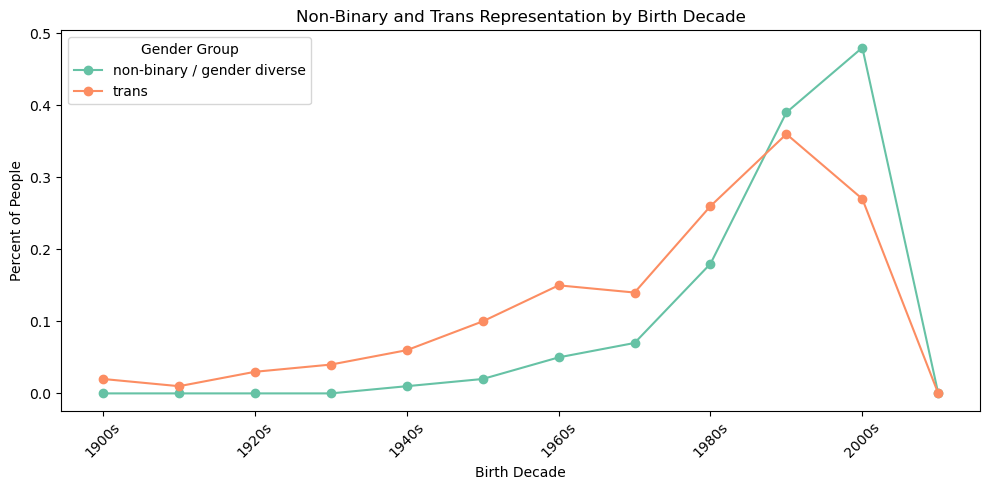

In [83]:
# Plot smaller gender groups separately because they get hidden when male/female are included
colors = sns.color_palette('Set2', n_colors=nb_trans_decade.shape[1])

ax = nb_trans_decade.plot(kind='line', marker='o', figsize=(10, 5), color=colors)

ax.set_title('Non-Binary and Trans Representation by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Gender Group')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Findings So Far

At this point, the strongest patterns are around occupation, gender, and time period. The dataset is dominated by males and likely shaped by documentation bias, especially around the United States and public-facing occupations.

The most interesting trend so far is how occupation representation changes over time. Sports and acting become much more represented among those born after the 2000s, while writers, public figures, and science/academia decline.

## Pattern Discovery Through Clustering

For the final part of this EDA, I want to see whether notable people naturally group into broad profiles based on features like occupation group, gender, country, and birth decade.

Since clustering models only understand numbers, I need to convert the categorical columns into numeric 0/1 columns first so the model can compare people based on shared traits rather than names or IDs.

In [85]:
# Build a clustering dataframe using only features that describe the person
cluster_df = df[['country_of_birth', 'gender_group', 'birth_decade', 'birth_month_name', 'occupation_groups']].copy()

cluster_df.head()

,country_of_birth,gender_group,birth_decade,birth_month_name,occupation_groups
0,Kingdom of Württemberg,male,1970s,July,Arts & Culture
1,Netherlands,male,1910s,October,Arts & Culture
2,Ukraine,male,1920s,November,Arts & Culture; Public Figures
3,Russia,male,1960s,February,Public Figures
4,Ukraine,male,1940s,July,Public Figures; Science & Academia


In [87]:
# Keep top countries so clustering is not overwhelmed by hundreds of tiny country categories
top_countries = cluster_df['country_of_birth'].value_counts().head(20).index

cluster_df['country_clean'] = cluster_df['country_of_birth'].where(
    cluster_df['country_of_birth'].isin(top_countries),'Other')


In [90]:
# Split occupation groups so the clustering can read each broad category separately
occ_dummies = cluster_df['occupation_groups'].str.get_dummies(sep='; ')

occ_dummies.head()

,Arts & Culture,Business,Public Figures,Science & Academia,Sports
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,1,0,0
3,0,0,1,0,0
4,0,0,1,1,0


In [93]:
# Encode the remaining categorical features so clustering can compare records numerically
cat_dummies = pd.get_dummies(
    cluster_df[['country_clean', 'gender_group', 'birth_decade', 'birth_month_name']],
    drop_first=False)

In [92]:
# Combine encoded personal/background fields with the occupation group flags
X_cluster = pd.concat([cat_dummies, occ_dummies], axis=1)

X_cluster.shape

(373183, 56)

In [94]:
# Scale the encoded features so each column is treated on a similar scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled.shape

(373183, 56)

In [95]:
# Test different cluster counts so I can choose a reasonable k instead of guessing
from sklearn.cluster import MiniBatchKMeans

k_values = range(2, 11)
inertia = []

for k in k_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia

[20129619.38081808,
 19374225.35239945,
 19299738.71628002,
 18789665.06691046,
 18728597.285382144,
 18530139.723990396,
 18253714.07336879,
 17744066.025224034,
 17424316.281026997]

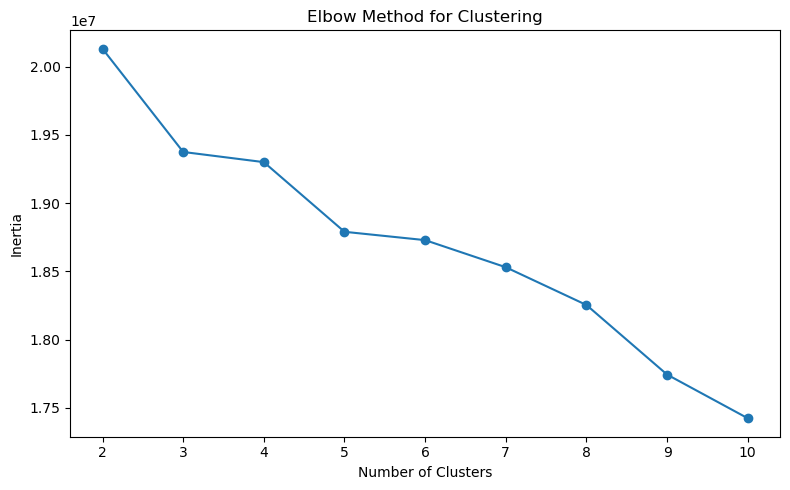

In [96]:
# Plot inertia to look for an elbow where adding more clusters stops helping as much
ax = pd.Series(inertia, index=k_values).plot(kind='line', marker='o', figsize=(8, 5))

ax.set_title('Elbow Method for Clustering')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Inertia')

plt.xticks(k_values)
plt.tight_layout()
plt.show()

Hard to see any elbow since we're working with categorical data

In [97]:
# Use 5 clusters as a practical starting point because the elbow is not perfectly clear
kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=10000)

cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels

df['cluster'].value_counts().sort_index()

cluster
0      9607
1     46295
2    130720
3    140862
4     45699
Name: count, dtype: int64

In [98]:
# Check the size of each cluster so I know whether the groups are balanced or weirdly uneven
cluster_sizes = df['cluster'].value_counts(normalize=True).mul(100).round(2)

cluster_sizes.sort_index()

cluster
0     2.57
1    12.41
2    35.03
3    37.75
4    12.25
Name: proportion, dtype: float64

In [99]:
# Profile clusters by occupation group so the groups become easier to interpret
cluster_occ = df.copy()

cluster_occ['occ_group'] = cluster_occ['occupation_groups'].str.split('; ')

cluster_occ = cluster_occ.explode('occ_group')

cluster_occ_mix = pd.crosstab(
    cluster_occ['cluster'],
    cluster_occ['occ_group'],
    normalize='index').mul(100).round(2)

cluster_occ_mix

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
cluster,,,,,
0,34.78,2.20,18.69,5.78,38.55
1,45.00,2.83,36.33,14.40,1.45
2,7.03,5.91,64.81,22.18,0.07
3,89.90,1.06,4.30,4.72,0.02
4,1.46,0.51,1.45,0.49,96.09


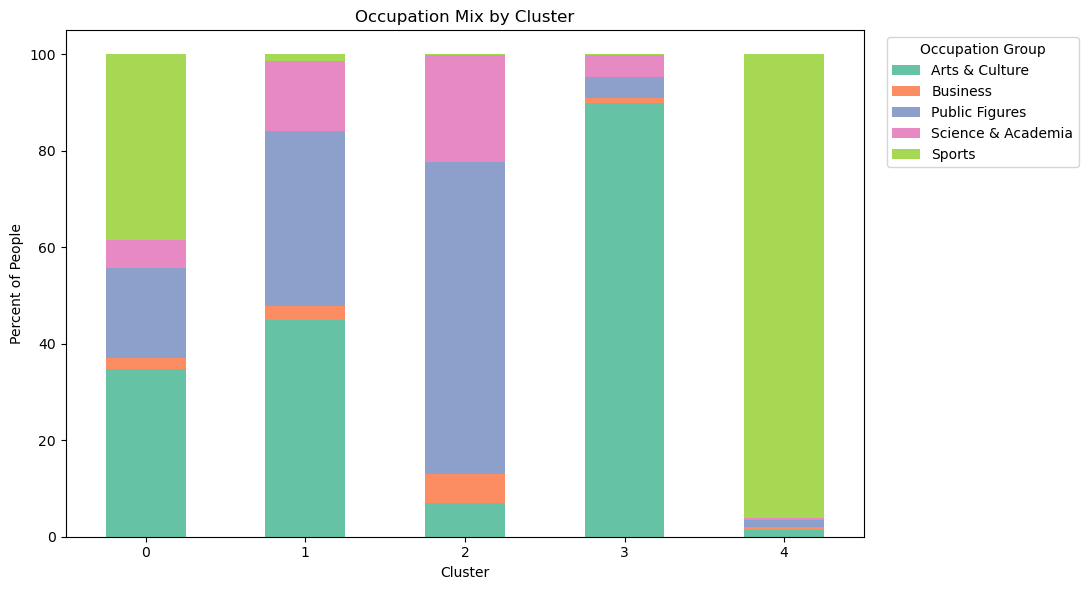

In [100]:
# Plot occupation makeup by cluster to see what kind of profiles the model found
colors = sns.color_palette('Set2', n_colors=cluster_occ_mix.shape[1])

ax = cluster_occ_mix.plot(kind='bar', stacked=True, figsize=(11, 6), color=colors)

ax.set_title('Occupation Mix by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [101]:
# Check gender makeup by cluster to see whether clusters also reflect gender patterns
cluster_gender = pd.crosstab(
    df['cluster'],
    df['gender_group'],
    normalize='index').mul(100).round(2)

cluster_gender

gender_group,female,male,non-binary / gender diverse,trans,undisclosed
cluster,,,,,
0,22.07,77.68,0.15,0.10,0.0
1,26.02,73.80,0.08,0.10,0.0
2,16.24,83.69,0.00,0.06,0.0
3,36.17,63.46,0.15,0.22,0.0
4,9.83,90.16,0.01,0.01,0.0


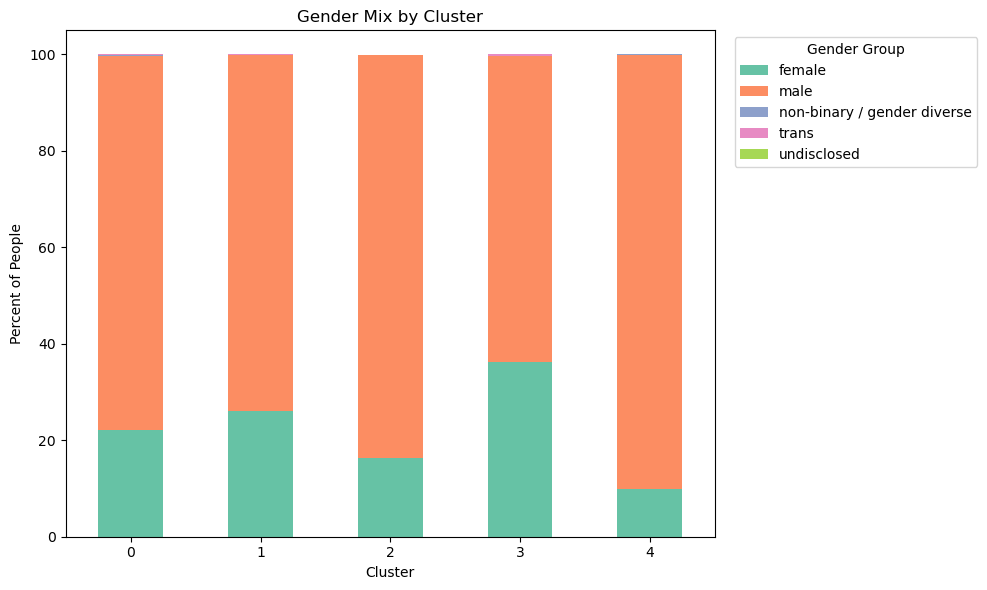

In [102]:
# Plot gender makeup by cluster
colors = sns.color_palette('Set2', n_colors=cluster_gender.shape[1])

ax = cluster_gender.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

ax.set_title('Gender Mix by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Percent of People')
ax.legend(title='Gender Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [103]:
# Check birth decade by cluster so I can see whether the model is also picking up time-period patterns
cluster_decade = pd.crosstab(
    df['cluster'],
    df['birth_decade'],
    normalize='index').mul(100).round(2)


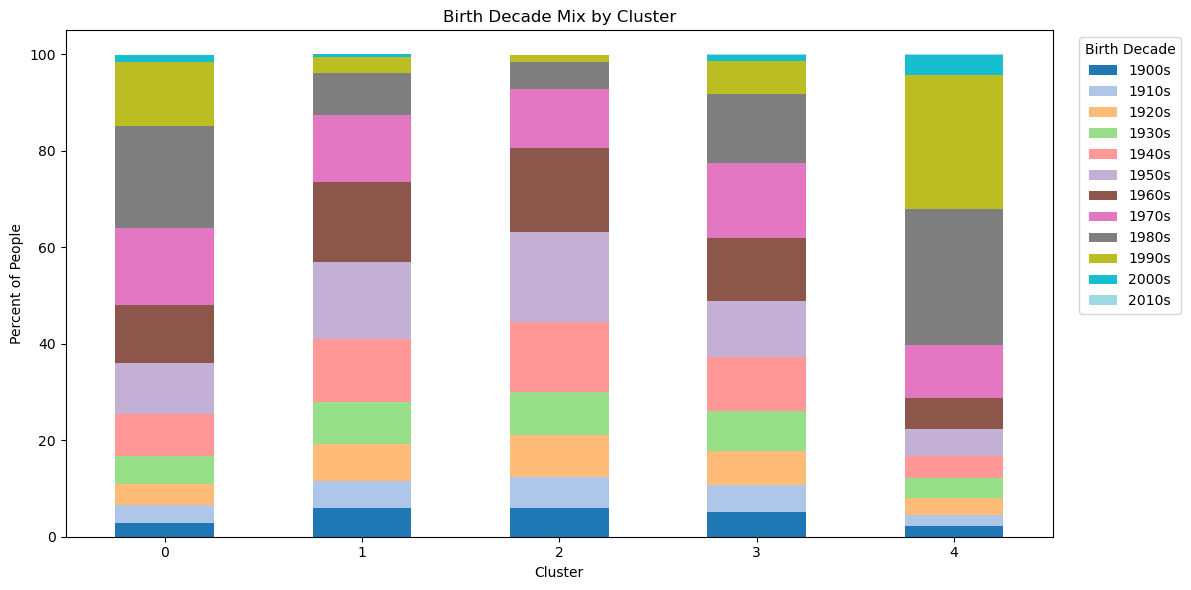

In [104]:
# Plot birth decade makeup by cluster
ax = cluster_decade.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

ax.set_title('Birth Decade Mix by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Percent of People')
ax.legend(title='Birth Decade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [105]:
# Add cleaned country labels to df so clusters can be profiled by geography
df['country_clean'] = df['country_of_birth'].where(
    df['country_of_birth'].isin(top_countries),
    'Other')

In [106]:
# Create the country mix table before plotting it
cluster_country = pd.crosstab(
    df['cluster'],
    df['country_clean'],
    normalize='index').mul(100).round(2)

cluster_country

country_clean,Argentina,Austria,Brazil,Canada,Czech Republic,France,Germany,Hungary,India,Italy,...,Netherlands,Norway,Other,Poland,Russia,Spain,Sweden,Ukraine,United Kingdom,United States
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.00,0.00,0.00,100.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.86,0.76,1.40,0.0,1.13,2.69,48.17,0.75,1.42,2.69,...,1.16,0.56,17.27,1.73,2.02,2.16,1.23,1.08,2.41,9.30
2,1.51,1.47,3.42,0.0,1.73,5.07,0.00,1.19,2.09,6.89,...,2.26,1.33,34.59,4.05,5.03,3.98,1.57,3.17,3.87,14.69
3,1.47,1.30,2.24,0.0,3.02,5.42,0.00,1.90,3.45,4.26,...,2.48,1.27,29.84,3.21,3.43,4.15,3.24,1.58,5.48,19.89
4,0.43,0.54,0.47,0.0,2.03,1.89,1.92,0.48,0.29,1.45,...,0.86,0.25,18.85,2.25,3.16,1.26,2.18,0.98,0.92,53.59


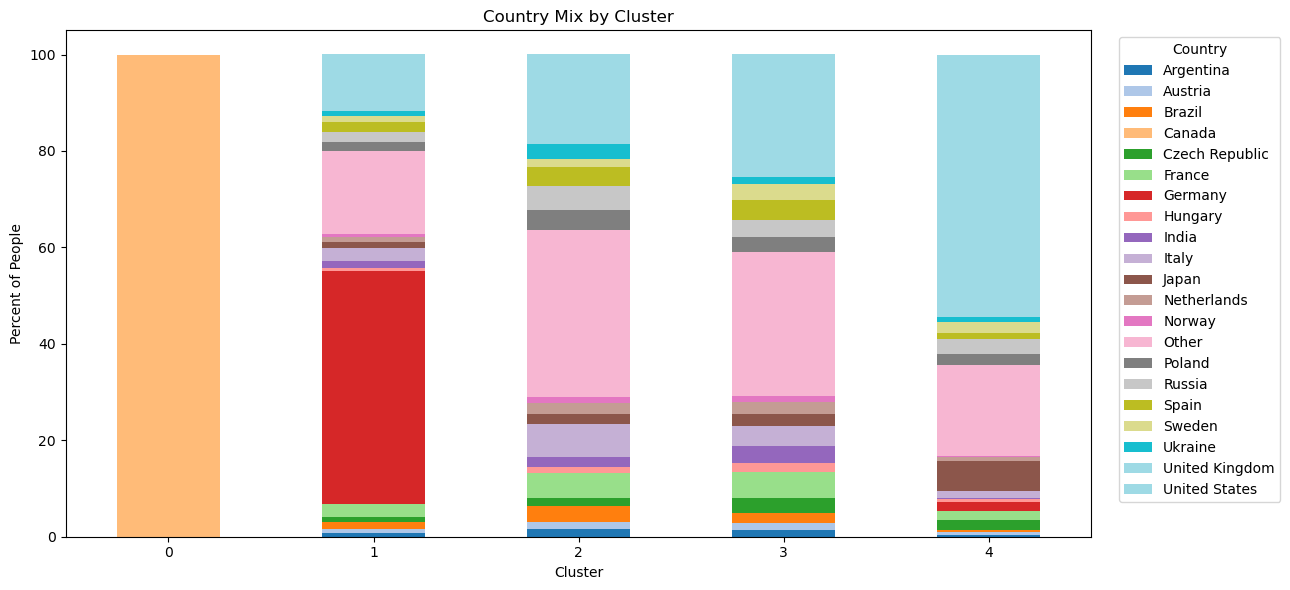

In [107]:
# Plot country makeup by cluster
ax = cluster_country.plot(kind='bar', stacked=True, figsize=(13, 6), colormap='tab20')

ax.set_title('Country Mix by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Percent of People')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [108]:
# Check cluster sizes so I can describe how large each group is
cluster_size = df['cluster'].value_counts(normalize=True).mul(100).round(2).sort_index()

cluster_size

cluster
0     2.57
1    12.41
2    35.03
3    37.75
4    12.25
Name: proportion, dtype: float64

In [110]:
# Pull the strongest occupation, gender, decade, and country patterns for each cluster
cluster_profile = pd.DataFrame({
    'cluster_size_pct': cluster_size,
    'top_occ': cluster_occ_mix.idxmax(axis=1),
    'top_gender': cluster_gender.idxmax(axis=1),
    'top_decade': cluster_decade.idxmax(axis=1),
    'top_country': cluster_country.idxmax(axis=1)})

cluster_profile

,cluster_size_pct,top_occ,top_gender,top_decade,top_country
cluster,,,,,
0,2.57,Sports,male,1980s,Canada
1,12.41,Arts & Culture,male,1960s,Germany
2,35.03,Public Figures,male,1950s,Other
3,37.75,Arts & Culture,male,1970s,Other
4,12.25,Sports,male,1980s,United States


### Clustering summary

The clustering model mostly grouped people by occupation type, which makes sense because occupation is one of the clearest features in the dataset. Some clusters were easy to interpret, especially the ones that leaned heavily toward Sports or Arts & Culture. Other clusters were more blended, with a mix of public figures, science, and cultural fields.

It was somewhat useful, but not definitive. The dataset still has obvious bias in who gets documented, especially across country, gender, and more modern public-facing occupations.

## Summary

### Most interesting findings

**January has a clear data quality issue.** January originally looked like it had way more birthdays than any other month, but the spike was almost entirely coming from January 1. That strongly suggests Jan 1 was used as a placeholder when the real birthday was unknown. Because of that, I created a cleaned birthday dataset that excludes Jan 1 records for the birth month and birth season analysis.

**Occupation patterns change a lot by birth decade.** Arts & Culture stays high across most decades, but Sports becomes much more common in later birth, especially after the 1960s. Public Figures and Science & Academia decline over time. This could reflect real cultural change, but it also probably reflects documentation bias. Modern athletes, entertainers (IMDB), and public figures are easier to track and more consistently documented.

**Birth season does not show a strong pattern.** After removing the January 1 placeholder issue, birthdays are pretty evenly distributed across seasons. There are small differences by occupation group, but nothing strong enough to suggest that season is a major factor in this dataset.

**Gender representation is heavily male.** The dataset is overwhelmingly male across occupation groups. Female representation is highest in Arts & Culture and lower in Sports and Science & Academia. Non-binary, gender diverse, and trans records are present, but the sample sizes are small, so those comparisons should be handled mindfully.

**Female representation increases over time.** The share of female notable people rises over the decades, especially after 1970s. Non-binary and trans representation also becomes more visible in the 1990s and later, even though the numbers are still very small.

**Country concentration is very strong.** The United States dominates the dataset in raw counts across almost every occupation group. When looking beyond the largest countries, smaller and mid-sized countries show more distinct profiles. Some lean more toward Sports, while others lean more toward Arts & Culture or Science & Academia.

**Clustering mostly grouped people by occupation.** The K-Means model produced clusters that were mainly organized around occupation type. There was a Sports-heavy cluster, Arts & Culture-heavy clusters, a Public Figures cluster, and a mixed cluster. The clusters were useful for pattern discovery, but they also reflected the dataset’s overall gender imbalance.





### Issues and limitations

- **January 1 placeholder dates:** Jan 1 appears far more often than expected, so birthday-related analysis uses a cleaned dataset without those records.
- **Date range limitation:** `date_of_birth` is limited to 1901–2015, so this analysis only covers modern notable people.
- **Documentation bias:** This dataset reflects who gets documented, not everyone who could be considered notable. US-born, English-language, and public-facing people are likely overrepresented.
- **Gender categories:** The original gender labels were broad and messy, so grouping them required some judgment. Smaller gender groups should be interpreted carefully.
- **Multi-occupation strings:** Some people belong to multiple occupation groups. They were split into multiple rows to do a group level count/analysis.


### Potential next steps

- **Compare to population birth data:** Use real birth distribution data to see whether notable people differ from the general population after removing Jan 1 placeholders (only able to find US births database between 1995-2015)
- **Go deeper into specific occupations:** Compare roles like actor, politician, athlete, writer, and scientist instead of only broad occupation groups.
- **Investigate the rise of Sports:** Check whether the increase is driven by specific sports, countries, decades, or gender groups.